## Introduction

Customer churn—when clients terminate their relationship with a financial institution—is a critical business challenge in the banking sector, directly affecting revenue and growth. Retaining existing customers is generally far more cost-effective than acquiring new ones. Studies suggest that acquiring a new customer can cost five to twenty-five times more than retaining one, and increasing retention by just 5% can boost profits by 25% to 95%.

This project addresses churn prediction using supervised learning. We analyze customer attributes such as demographics, account activity, and transaction behavior to identify patterns associated with attrition.

Using data from the Kaggle Playground Series - Season 4, Episode 1 (2024), we build and evaluate machine learning models to identify customers at risk of closing their accounts. This enables banks to implement proactive retention strategies—such as personalized offers or loyalty programs—to improve customer lifetime value.

Beyond prediction, our goal is to understand the factors driving churn, providing actionable insights for improving customer experience and reducing attrition.


> The dataset is available at the following link: [Kaggle Playground Series - Season 4, Episode 1](https://www.kaggle.com/competitions/playground-series-s4e1/data).


### Project Objectives
1. **Apply supervised learning techniques** to classify customers as likely to churn or remain
2. **Develop interpretable models** that identify key factors influencing customer decisions
3. **Compare multiple algorithms** to determine optimal prediction approaches
4. **Demonstrate a complete data science workflow** from exploration to evaluation


This project represents a practical application of machine learning to a real-world business problem, showcasing how data science can deliver tangible business value by enabling proactive customer relationship management.



We will follow an end-to-end machine learning pipeline:

    Exploratory Data Analysis (EDA): Understand data structure, distributions, and potential issues (e.g., imbalance, missing values).

    Data Preprocessing: Handle missing values, encode categorical features, scale numerical variables, and select relevant attributes.

    Problem Definition: Define the target variable and classification goal.

    Model Development: Train and tune various machine learning models.

    Evaluation: Assess models using metrics like Accuracy, Precision, Recall, F1-score, ROC curves, and confusion matrices.

This project is implemented in Python using libraries such as Pandas, NumPy, Scikit-learn, Matplotlib, and Seaborn, aiming to produce a well-documented and reproducible analysis of churn prediction in banking.


![ML Workflow](image.png)


## Project Implementation

Having established the importance of customer churn prediction and our project objectives, we now begin the implementation phase of our analysis. The following sections detail our step-by-step approach to solving this supervised learning problem.

We start by importing the necessary libraries and loading the dataset. Then, we proceed with initial data exploration to understand the characteristics of our data before moving on to more detailed analysis and model building. Each stage of the workflow is documented with explanations and visualizations to provide a comprehensive understanding of the prediction process.

Our implementation follows industry best practices for data science projects, emphasizing reproducibility, proper evaluation, and practical insights that can inform business decisions in the banking sector.

## Data Initialization and Visualization

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train_data = pd.read_csv("data/train.csv")  
print(train_data.dtypes)
print("Data loaded!")

id                   int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                float64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard          float64
IsActiveMember     float64
EstimatedSalary    float64
Exited               int64
dtype: object
Data loaded!


### Visualization of Part of the Dataset
 

In [2]:
train_data.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15674932,Okwudilichukwu,668,France,Male,33.0,3,0.00,2,1.0,0.0,181449.97,0
1,1,15749177,Okwudiliolisa,627,France,Male,33.0,1,0.00,2,1.0,1.0,49503.50,0
2,2,15694510,Hsueh,678,France,Male,40.0,10,0.00,2,1.0,0.0,184866.69,0
3,3,15741417,Kao,581,France,Male,34.0,2,148882.54,1,1.0,1.0,84560.88,0
4,4,15766172,Chiemenam,716,Spain,Male,33.0,5,0.00,2,1.0,1.0,15068.83,0


After reviewing the dataset, we observe that the target variable is **Exited**, a binary indicator where 1 means the customer has left the bank, and 0 otherwise. The dataset includes various features describing customer demographics, account details, and transactions.

And with that we saw that the table has columns that are not needed for the analysis, such as **ID**, **CustomerId**, and **Surname**. These columns do not provide relevant information for predicting customer churn and can be safely removed from the dataset.

In [3]:
# Drop columns only if they exist in the DataFrame
columns_to_drop = ['id', 'CustomerId', 'Surname']
train_data.drop(columns=[col for col in columns_to_drop if col in train_data.columns], inplace=True)




### Info of the Dataset


In [4]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165034 entries, 0 to 165033
Data columns (total 11 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   CreditScore      165034 non-null  int64  
 1   Geography        165034 non-null  object 
 2   Gender           165034 non-null  object 
 3   Age              165034 non-null  float64
 4   Tenure           165034 non-null  int64  
 5   Balance          165034 non-null  float64
 6   NumOfProducts    165034 non-null  int64  
 7   HasCrCard        165034 non-null  float64
 8   IsActiveMember   165034 non-null  float64
 9   EstimatedSalary  165034 non-null  float64
 10  Exited           165034 non-null  int64  
dtypes: float64(5), int64(4), object(2)
memory usage: 13.9+ MB


### Missing Values vizualization

In [5]:
train_data.isnull().sum()


CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [6]:
# Calcular valores ausentes e porcentagens
missing_values = train_data.isnull().sum()
missing_percent = (missing_values / len(train_data)) * 100

# Filtrar apenas colunas com valores ausentes
missing_df = pd.DataFrame({
    'Column': missing_values.index,
    'Missing': missing_values.values,
    'Percent': missing_percent.values
})
missing_df = missing_df[missing_df['Missing'] > 0].sort_values('Missing', ascending=False)

# Evitar plot vazio caso nenhuma coluna tenha valores ausentes
if not missing_df.empty:
    # Configuração do gráfico
    plt.figure(figsize=(14, 8))
    plt.style.use('seaborn-v0_8-whitegrid')

    ax = sns.barplot(
        x='Column', y='Missing', 
        data=missing_df,
        palette='#d73027', 
        edgecolor='black'
    )

    plt.title("Análise de Valores Ausentes por Coluna", fontsize=16, fontweight='bold', pad=20)
    plt.ylabel("Número de Valores Ausentes", fontsize=12, fontweight='bold')
    plt.xlabel("Colunas do Dataset", fontsize=12, fontweight='bold')
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    for i, row in enumerate(missing_df.itertuples()):
        label_text = f"{int(row.Missing)} ({row.Percent:.1f}%)"
        ax.text(i, row.Missing + 0.5, label_text, ha='center', va='bottom', fontweight='bold', color='black')

    total_missing = missing_values.sum()
    total_cells = train_data.size
    total_percent = (total_missing / total_cells) * 100

    summary = (
        f"Resumo do Dataset (Registros: {len(train_data):,}, Campos: {train_data.shape[1]})\n"
        f"Total de valores ausentes: {total_missing:,} de {total_cells:,} células ({total_percent:.2f}%)\n"
        f"Colunas com valores ausentes: {missing_df.shape[0]} de {train_data.shape[1]} "
        f"({(missing_df.shape[0]/train_data.shape[1]*100):.1f}%)"
    )

    plt.figtext(0.5, 0.01, summary, ha='center', fontsize=11, 
                bbox={"facecolor":"#f0f0f0", "edgecolor":"#cccccc", "alpha":1.0, "boxstyle":"round,pad=0.8"})

    plt.tight_layout(rect=[0, 0.08, 1, 0.98])
    plt.show()

else:
    print("Nenhuma coluna com valores ausentes encontrada no dataset.")


Nenhuma coluna com valores ausentes encontrada no dataset.


Since We do not have any missing values in the dataset, we can proceed with the analysis without needing to handle missing data. This is a positive aspect of our dataset, as it simplifies the preprocessing steps and allows us to focus on feature engineering and model development.

### Description of the Dataset

In [7]:
desc = train_data.describe()
desc = desc.drop('count')
desc

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
mean,656.454373,38.125888,5.020353,55478.086689,1.554455,0.753954,0.497770,112574.822734,0.211599
std,80.103340,8.867205,2.806159,62817.663278,0.547154,0.430707,0.499997,50292.865585,0.408443
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000
25%,597.000000,32.000000,3.000000,0.000000,1.000000,1.000000,0.000000,74637.570000,0.000000
50%,659.000000,37.000000,5.000000,0.000000,2.000000,1.000000,0.000000,117948.000000,0.000000
75%,710.000000,42.000000,7.000000,119939.517500,2.000000,1.000000,1.000000,155152.467500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199992.480000,1.000000


## Data Processing

## Outlier Analysis

This section focuses on identifying and handling outliers in the dataset. Outliers can significantly affect the performance of machine learning models, so it is crucial to detect and address them appropriately.

so we will use the Z-score method to identify outliers in the numerical features of the dataset. The Z-score indicates how many standard deviations a data point is from the mean. A common threshold for identifying outliers is a Z-score greater than 3 or less than -3.

In [8]:
# Define categorical and numerical features
categorical_features = ["Geography", "Gender"]
numerical_features = [col for col in train_data.columns if col not in categorical_features + ['Exited']]



### Outlier Calculation

In [9]:
# Função para calcular limites IQR que será usada em todas as células
def calculate_outlier_bounds(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return Q1, Q3, IQR, lower_bound, upper_bound

# Função para obter estatísticas de outliers
def get_outlier_stats(data, column):
    Q1, Q3, IQR, lower_bound, upper_bound = calculate_outlier_bounds(data, column)
    
    # Identificar outliers
    outliers_low = data[data[column] < lower_bound]
    outliers_high = data[data[column] > upper_bound]
    outliers_all = pd.concat([outliers_low, outliers_high])
    
    # Calcular estatísticas
    stats = {
        "Total Outliers": len(outliers_all),
        "% do Dataset": len(outliers_all) / len(data) * 100,
        "Outliers Inferiores": len(outliers_low),
        "Outliers Superiores": len(outliers_high),
        "Limite Inferior": lower_bound,
        "Limite Superior": upper_bound,
        "Menor Valor": data[column].min(),
        "Maior Valor": data[column].max(),
        "Taxa de Churn (Geral)": data['Exited'].mean() * 100,
        "Taxa de Churn (Outliers)": outliers_all['Exited'].mean() * 100 if len(outliers_all) > 0 else 0
    }
    
    return stats, outliers_low, outliers_high, outliers_all


### Age Outliers analysis


=== Análise de Outliers: Idade (Age) ===

Total de outliers: 6394 (3.87% do dataset)
Outliers inferiores: 0 (idade < 17.0)
Outliers superiores: 6394 (idade > 57.0)
Faixa total: 18.0 a 92.0 anos
Taxa de churn geral: 21.16%
Taxa de churn entre outliers: 38.38%

Estatísticas dos outliers de idade:
Média de idade dos outliers: 63.3 anos
Mediana de idade dos outliers: 62.0 anos

Distribuição de outliers por geografia:
Geography
France     53.4
Germany    24.2
Spain      22.4
Name: proportion, dtype: float64
Taxa de churn em outliers superiores: 38.38%


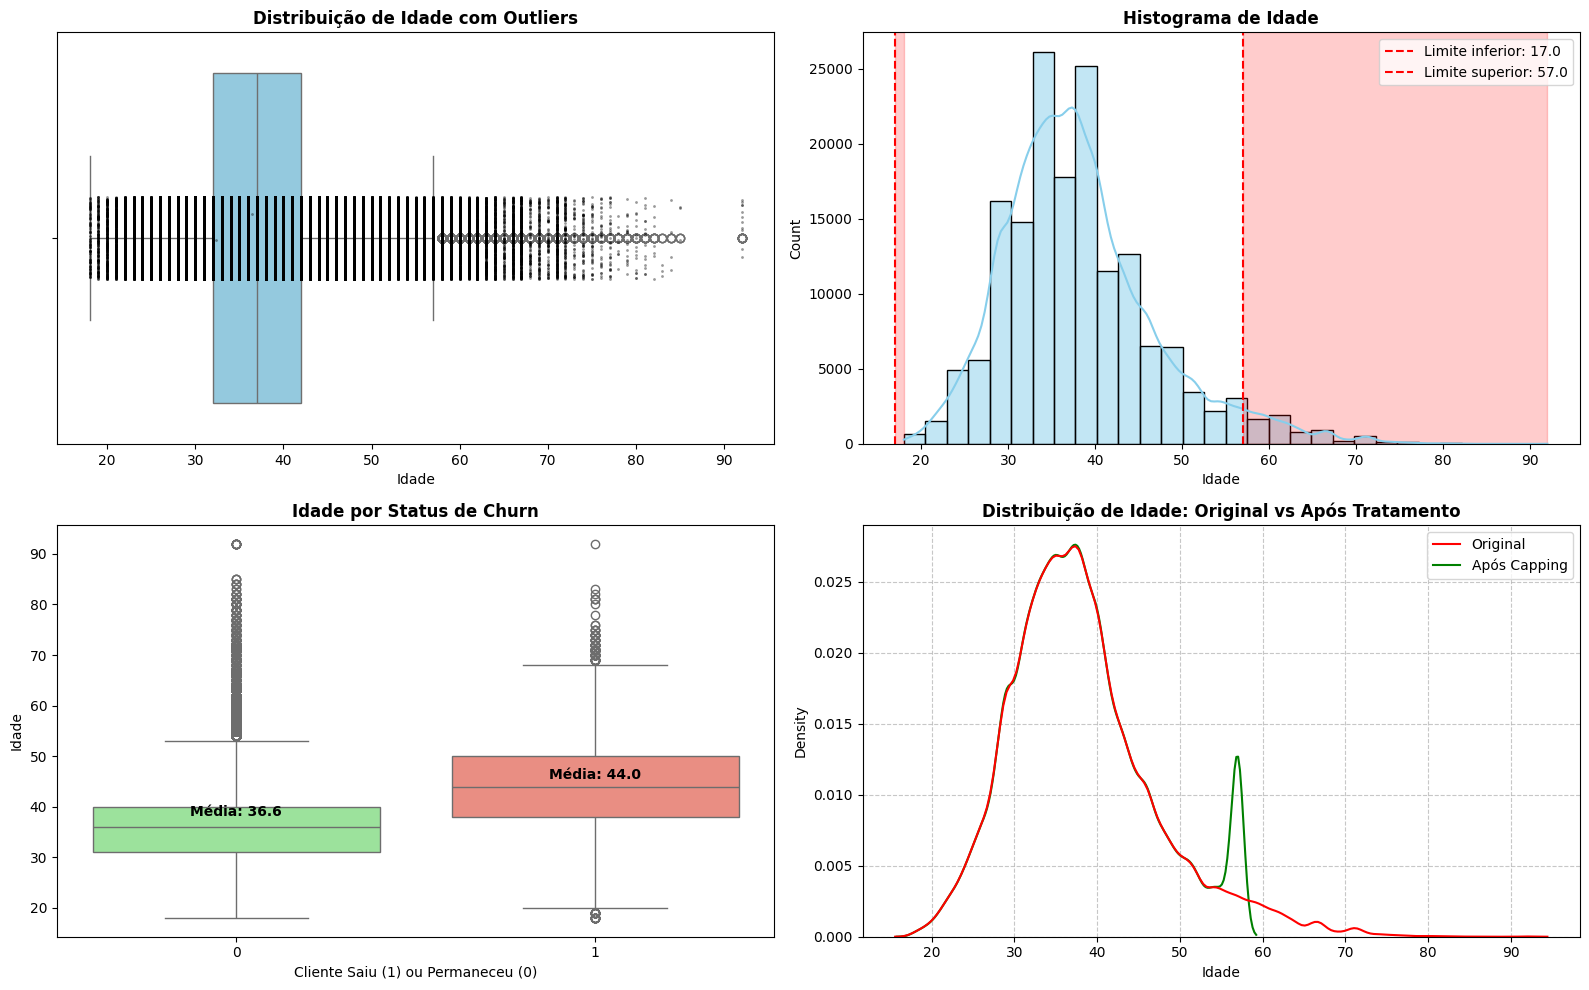

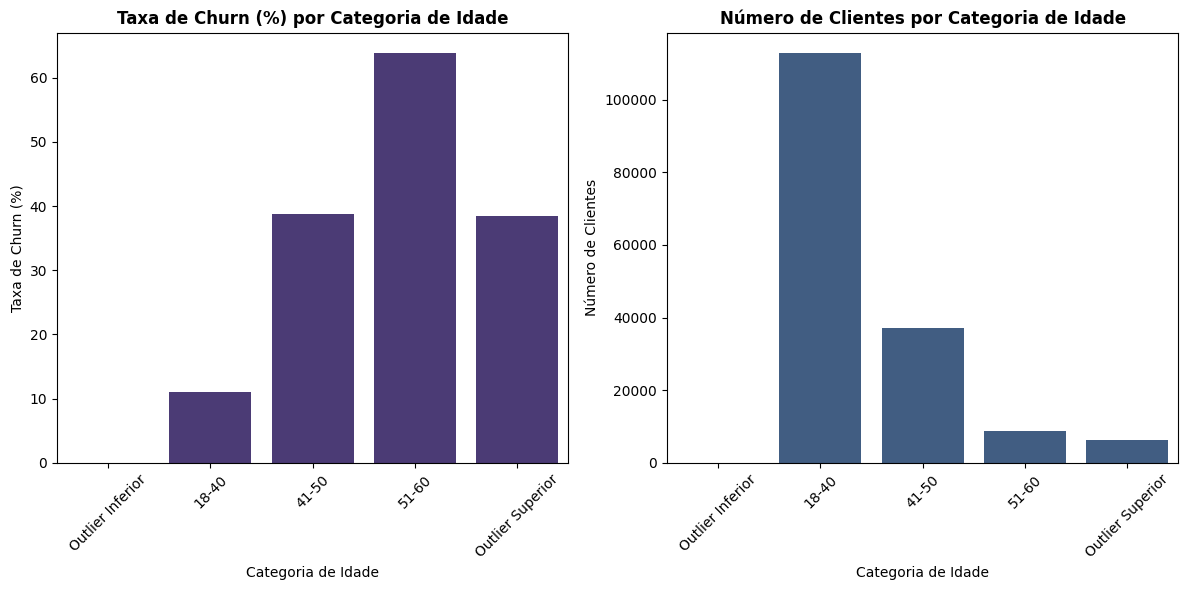

In [10]:
# Introdução à análise de outliers na idade
print("\n=== Análise de Outliers: Idade (Age) ===\n")

# Cálculo de estatísticas de outliers
age_stats, age_out_low, age_out_high, age_outliers = get_outlier_stats(train_data, 'Age')

# Exibição de estatísticas detalhadas
print(f"Total de outliers: {age_stats['Total Outliers']} ({age_stats['% do Dataset']:.2f}% do dataset)")
print(f"Outliers inferiores: {age_stats['Outliers Inferiores']} (idade < {age_stats['Limite Inferior']:.1f})")
print(f"Outliers superiores: {age_stats['Outliers Superiores']} (idade > {age_stats['Limite Superior']:.1f})")
print(f"Faixa total: {age_stats['Menor Valor']} a {age_stats['Maior Valor']} anos")
print(f"Taxa de churn geral: {age_stats['Taxa de Churn (Geral)']:.2f}%")
print(f"Taxa de churn entre outliers: {age_stats['Taxa de Churn (Outliers)']:.2f}%")

# Análise mais detalhada dos outliers
if len(age_outliers) > 0:
    print("\nEstatísticas dos outliers de idade:")
    print(f"Média de idade dos outliers: {age_outliers['Age'].mean():.1f} anos")
    print(f"Mediana de idade dos outliers: {age_outliers['Age'].median():.1f} anos")
    print("\nDistribuição de outliers por geografia:")
    print(age_outliers['Geography'].value_counts(normalize=True).mul(100).round(1))
    
    # Análise de churn nos outliers por tipo
    if len(age_out_low) > 0:
        print(f"\nTaxa de churn em outliers inferiores: {age_out_low['Exited'].mean()*100:.2f}%")
    if len(age_out_high) > 0:
        print(f"Taxa de churn em outliers superiores: {age_out_high['Exited'].mean()*100:.2f}%")

# Visualização aprimorada
plt.figure(figsize=(16, 10))

# Boxplot principal com pontos de outliers visíveis
plt.subplot(2, 2, 1)
sns.boxplot(x=train_data['Age'], color='skyblue')
sns.stripplot(x=train_data['Age'], color='black', alpha=0.4, size=2)
plt.title('Distribuição de Idade com Outliers', fontweight='bold', size=12)
plt.xlabel('Idade')

# Histograma com KDE e limites de outliers
plt.subplot(2, 2, 2)
sns.histplot(train_data['Age'], kde=True, bins=30, color='skyblue')
plt.axvline(age_stats['Limite Inferior'], color='r', linestyle='--', 
            label=f"Limite inferior: {age_stats['Limite Inferior']:.1f}")
plt.axvline(age_stats['Limite Superior'], color='r', linestyle='--', 
            label=f"Limite superior: {age_stats['Limite Superior']:.1f}")
# Destacar áreas de outlier
plt.axvspan(age_stats['Menor Valor'], age_stats['Limite Inferior'], alpha=0.2, color='red')
plt.axvspan(age_stats['Limite Superior'], age_stats['Maior Valor'], alpha=0.2, color='red')
plt.title('Histograma de Idade', fontweight='bold', size=12)
plt.xlabel('Idade')
plt.legend()

# Boxplot por status de churn com média e mediana
plt.subplot(2, 2, 3)
ax = sns.boxplot(x='Exited', y='Age', data=train_data, hue='Exited', 
                 palette=['lightgreen', 'salmon'], legend=False)
# Adicionar médias ao gráfico
means = train_data.groupby('Exited')['Age'].mean().values
for i, mean in enumerate(means):
    ax.text(i, mean + 1, f'Média: {mean:.1f}', ha='center', va='bottom', fontweight='bold')
plt.title('Idade por Status de Churn', fontweight='bold', size=12)
plt.xlabel('Cliente Saiu (1) ou Permaneceu (0)')
plt.ylabel('Idade')

# Tratamento sugerido
plt.subplot(2, 2, 4)
# Capping para exemplo
age_capped = train_data['Age'].clip(lower=age_stats['Limite Inferior'], upper=age_stats['Limite Superior'])
before_after = pd.DataFrame({
    'Original': train_data['Age'],
    'Após Capping': age_capped
})
sns.kdeplot(data=before_after, palette=['red', 'green'])
plt.title('Distribuição de Idade: Original vs Após Tratamento', fontweight='bold', size=12)
plt.xlabel('Idade')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Impacto dos outliers no churn
plt.figure(figsize=(12, 6))
# Categorizar idades
age_categories = pd.cut(
    train_data['Age'],
    bins=[0, age_stats['Limite Inferior']-0.1, 40, 50, age_stats['Limite Superior'], 100],
    labels=['Outlier Inferior', '18-40', '41-50', '51-60', 'Outlier Superior']
)
# Calcular taxa de churn por categoria
churn_by_age = train_data.groupby(age_categories, observed=True)['Exited'].agg(['mean', 'count'])
churn_by_age['mean'] = churn_by_age['mean'] * 100  # Converter para percentagem

# Plotar taxa de churn por categoria de idade
ax1 = plt.subplot(1, 2, 1)
sns.barplot(x=churn_by_age.index, y=churn_by_age['mean'], color=sns.color_palette('viridis')[0])
plt.title('Taxa de Churn (%) por Categoria de Idade', fontweight='bold')
plt.ylabel('Taxa de Churn (%)')
plt.xlabel('Categoria de Idade')
plt.xticks(rotation=45)

# Plotar contagem de clientes por categoria
ax2 = plt.subplot(1, 2, 2)
sns.barplot(x=churn_by_age.index, y=churn_by_age['count'], color=sns.color_palette('viridis')[1])
plt.title('Número de Clientes por Categoria de Idade', fontweight='bold')
plt.ylabel('Número de Clientes')
plt.xlabel('Categoria de Idade')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### CreditScore Outliers analysis


=== Análise de Outliers: Score de Crédito ===

Total de outliers: 253 (0.15% do dataset)
Outliers inferiores: 253 (score < 427.5)
Outliers superiores: 0 (score > 879.5)
Faixa total: 350 a 850
Taxa de churn geral: 21.16%
Taxa de churn entre outliers: 22.53%

Estatísticas dos outliers de Credit Score:
Média de score dos outliers: 405.8
Mediana de score dos outliers: 414.0

Distribuição de outliers por geografia:
Geography
France     60.5
Spain      24.1
Germany    15.4
Name: proportion, dtype: float64

Taxa de churn em outliers inferiores: 22.53%


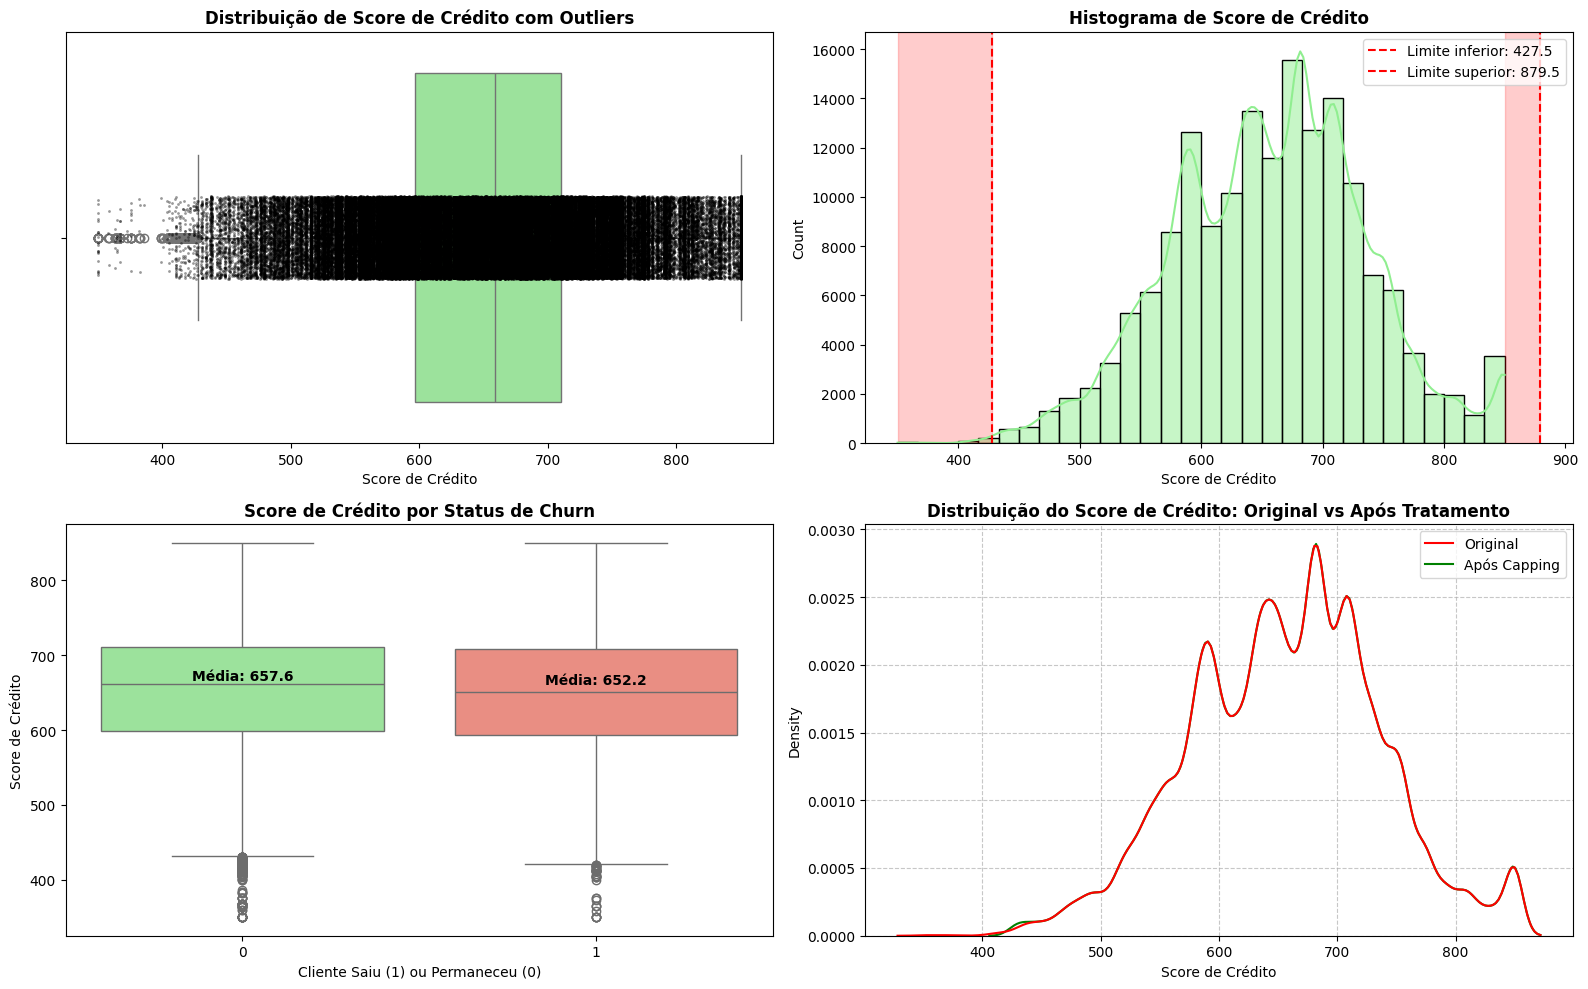

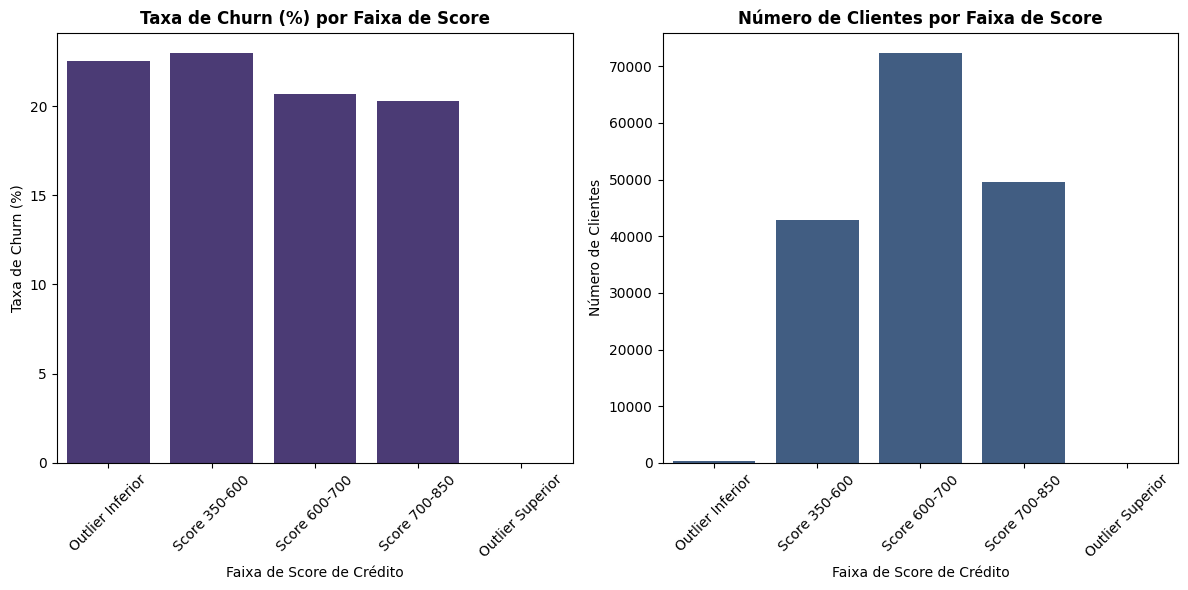

In [11]:
# Análise de outliers na coluna CreditScore
print("\n=== Análise de Outliers: Score de Crédito ===\n")

# Cálculo de estatísticas de outliers
credit_stats, credit_out_low, credit_out_high, credit_outliers = get_outlier_stats(train_data, 'CreditScore')

# Exibição de estatísticas detalhadas
print(f"Total de outliers: {credit_stats['Total Outliers']} ({credit_stats['% do Dataset']:.2f}% do dataset)")
print(f"Outliers inferiores: {credit_stats['Outliers Inferiores']} (score < {credit_stats['Limite Inferior']:.1f})")
print(f"Outliers superiores: {credit_stats['Outliers Superiores']} (score > {credit_stats['Limite Superior']:.1f})")
print(f"Faixa total: {credit_stats['Menor Valor']} a {credit_stats['Maior Valor']}")
print(f"Taxa de churn geral: {credit_stats['Taxa de Churn (Geral)']:.2f}%")
print(f"Taxa de churn entre outliers: {credit_stats['Taxa de Churn (Outliers)']:.2f}%")

# Análise mais detalhada dos outliers
if len(credit_outliers) > 0:
    print("\nEstatísticas dos outliers de Credit Score:")
    print(f"Média de score dos outliers: {credit_outliers['CreditScore'].mean():.1f}")
    print(f"Mediana de score dos outliers: {credit_outliers['CreditScore'].median():.1f}")
    print("\nDistribuição de outliers por geografia:")
    print(credit_outliers['Geography'].value_counts(normalize=True).mul(100).round(1))
    
    # Análise de churn nos outliers por tipo
    if len(credit_out_low) > 0:
        print(f"\nTaxa de churn em outliers inferiores: {credit_out_low['Exited'].mean()*100:.2f}%")
    if len(credit_out_high) > 0:
        print(f"Taxa de churn em outliers superiores: {credit_out_high['Exited'].mean()*100:.2f}%")

# Visualização aprimorada
plt.figure(figsize=(16, 10))

# Boxplot principal com pontos de outliers visíveis
plt.subplot(2, 2, 1)
sns.boxplot(x=train_data['CreditScore'], color='lightgreen')
sns.stripplot(x=train_data['CreditScore'], color='black', alpha=0.4, size=2)
plt.title('Distribuição de Score de Crédito com Outliers', fontweight='bold', size=12)
plt.xlabel('Score de Crédito')

# Histograma com KDE e limites de outliers
plt.subplot(2, 2, 2)
sns.histplot(train_data['CreditScore'], kde=True, bins=30, color='lightgreen')
plt.axvline(credit_stats['Limite Inferior'], color='r', linestyle='--', 
            label=f"Limite inferior: {credit_stats['Limite Inferior']:.1f}")
plt.axvline(credit_stats['Limite Superior'], color='r', linestyle='--', 
            label=f"Limite superior: {credit_stats['Limite Superior']:.1f}")
# Destacar áreas de outlier
plt.axvspan(credit_stats['Menor Valor'], credit_stats['Limite Inferior'], alpha=0.2, color='red')
plt.axvspan(credit_stats['Limite Superior'], credit_stats['Maior Valor'], alpha=0.2, color='red')
plt.title('Histograma de Score de Crédito', fontweight='bold', size=12)
plt.xlabel('Score de Crédito')
plt.legend()

# Boxplot por status de churn com médias
plt.subplot(2, 2, 3)
ax = sns.boxplot(x='Exited', y='CreditScore', data=train_data, hue='Exited', 
                palette=['lightgreen', 'salmon'], legend=False)
# Adicionar médias ao gráfico
means = train_data.groupby('Exited')['CreditScore'].mean().values
for i, mean in enumerate(means):
    ax.text(i, mean + 5, f'Média: {mean:.1f}', ha='center', va='bottom', fontweight='bold')
plt.title('Score de Crédito por Status de Churn', fontweight='bold', size=12)
plt.xlabel('Cliente Saiu (1) ou Permaneceu (0)')
plt.ylabel('Score de Crédito')

# Tratamento sugerido: comparativo antes e depois
plt.subplot(2, 2, 4)
# Capping para exemplo
credit_capped = train_data['CreditScore'].clip(lower=credit_stats['Limite Inferior'], upper=credit_stats['Limite Superior'])
before_after = pd.DataFrame({
    'Original': train_data['CreditScore'],
    'Após Capping': credit_capped
})
sns.kdeplot(data=before_after, palette=['red', 'green'])
plt.title('Distribuição do Score de Crédito: Original vs Após Tratamento', fontweight='bold', size=12)
plt.xlabel('Score de Crédito')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Análise adicional: relação entre credit score e churn
plt.figure(figsize=(12, 6))
# Criar faixas de score de crédito
score_categories = pd.cut(
    train_data['CreditScore'],
    bins=[300, credit_stats['Limite Inferior']-0.1, 600, 700, credit_stats['Limite Superior'], 900],
    labels=['Outlier Inferior', 'Score 350-600', 'Score 600-700', 'Score 700-850', 'Outlier Superior']
)

# Calcular taxa de churn por categoria de score
churn_by_score = train_data.groupby(score_categories, observed=True)['Exited'].agg(['mean', 'count'])
churn_by_score['mean'] = churn_by_score['mean'] * 100  # Converter para percentagem

# Plotar taxa de churn por categoria de score
ax1 = plt.subplot(1, 2, 1)
sns.barplot(x=churn_by_score.index, y=churn_by_score['mean'], color=sns.color_palette('viridis')[0])
plt.title('Taxa de Churn (%) por Faixa de Score', fontweight='bold')
plt.ylabel('Taxa de Churn (%)')
plt.xlabel('Faixa de Score de Crédito')
plt.xticks(rotation=45)

# Plotar contagem de clientes por categoria de score
ax2 = plt.subplot(1, 2, 2)
sns.barplot(x=churn_by_score.index, y=churn_by_score['count'], color=sns.color_palette('viridis')[1])
plt.title('Número de Clientes por Faixa de Score', fontweight='bold')
plt.ylabel('Número de Clientes')
plt.xlabel('Faixa de Score de Crédito')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Balance Outliers analysis


=== Análise de Outliers: Saldo (Balance) ===

Total de outliers: 0 (0.00% do dataset)
Outliers inferiores: 0 (saldo < -179909.28)
Outliers superiores: 0 (saldo > 299848.79)
Faixa total: 0.00 a 250898.09
Casos com saldo zero: 89648 (54.32%)
Taxa de churn geral: 21.16%
Taxa de churn entre outliers: 0.00%


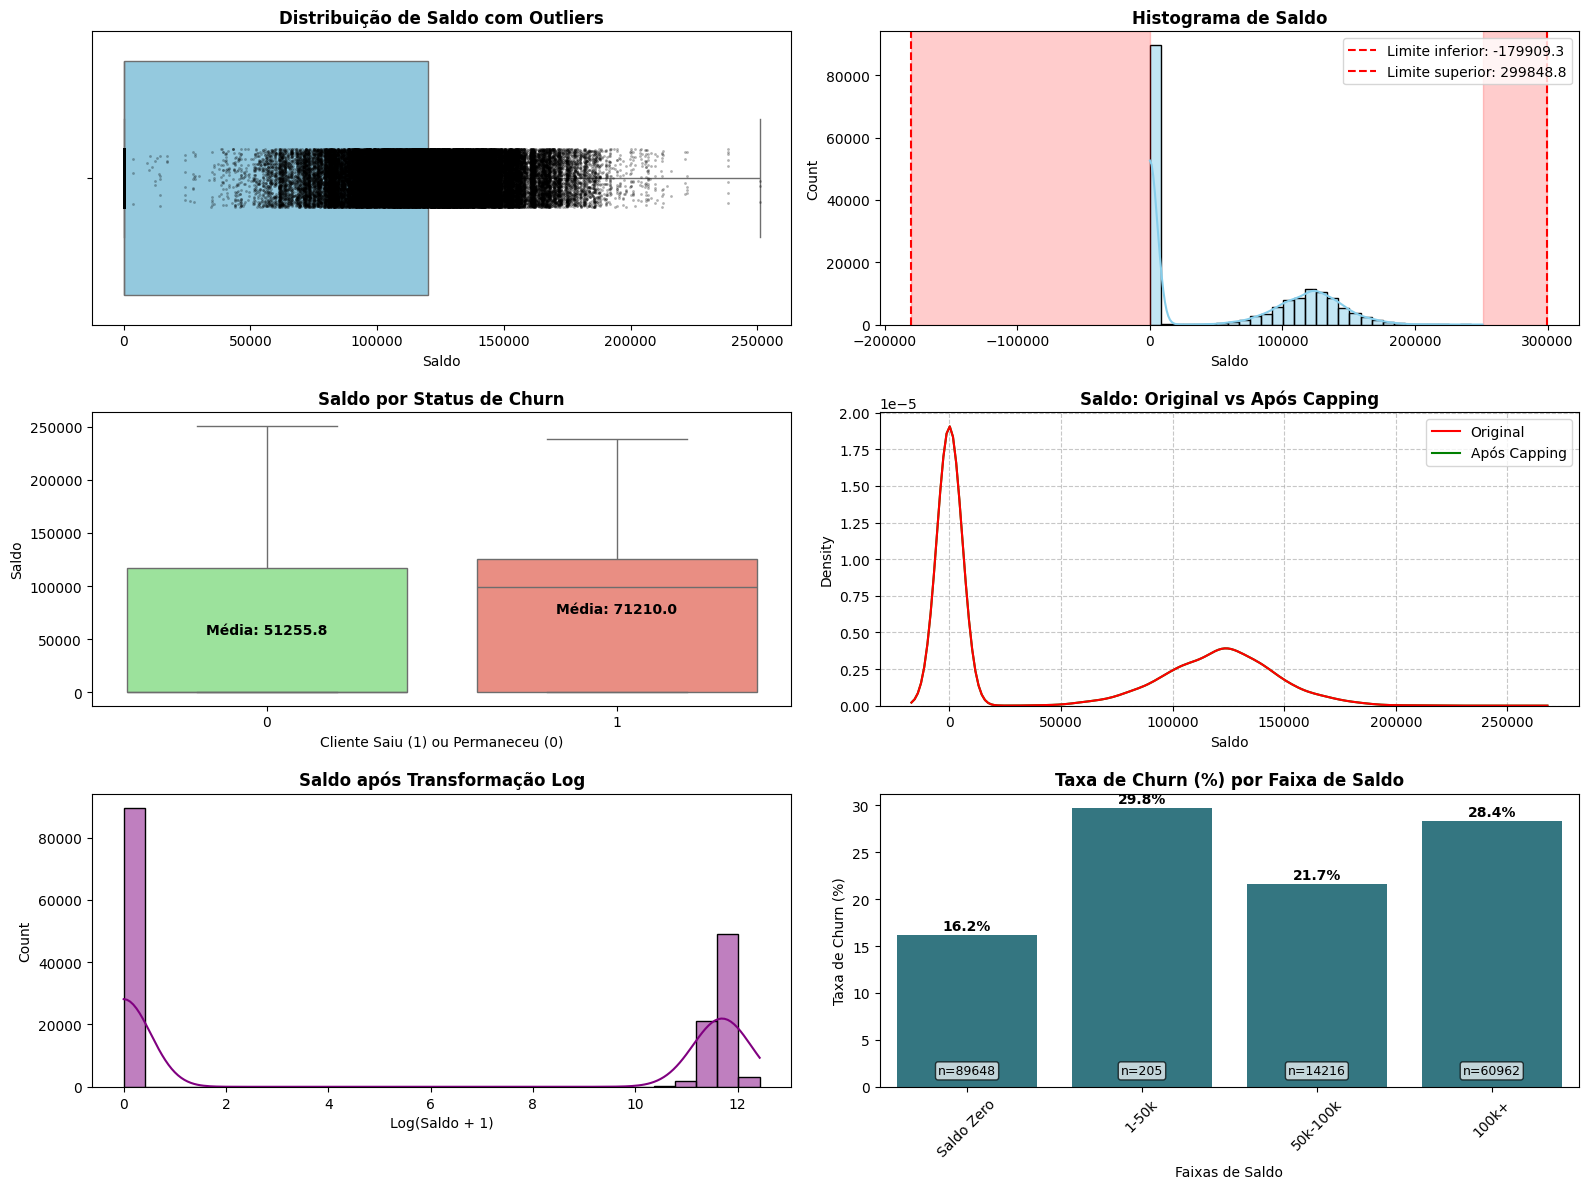

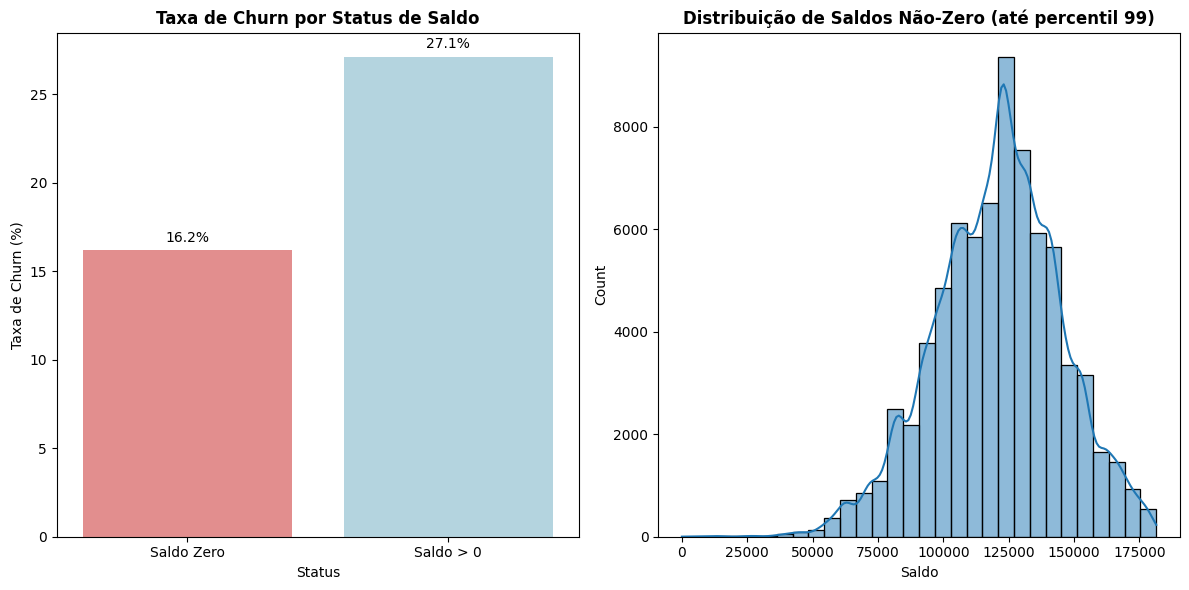

In [12]:
# Análise de outliers na coluna Balance
print("\n=== Análise de Outliers: Saldo (Balance) ===\n")

# Cálculo de estatísticas de outliers
balance_stats, balance_out_low, balance_out_high, balance_outliers = get_outlier_stats(train_data, 'Balance')

# Exibição de estatísticas detalhadas
print(f"Total de outliers: {balance_stats['Total Outliers']} ({balance_stats['% do Dataset']:.2f}% do dataset)")
print(f"Outliers inferiores: {balance_stats['Outliers Inferiores']} (saldo < {balance_stats['Limite Inferior']:.2f})")
print(f"Outliers superiores: {balance_stats['Outliers Superiores']} (saldo > {balance_stats['Limite Superior']:.2f})")
print(f"Faixa total: {balance_stats['Menor Valor']:.2f} a {balance_stats['Maior Valor']:.2f}")
print(f"Casos com saldo zero: {(train_data['Balance'] == 0).sum()} ({(train_data['Balance'] == 0).mean()*100:.2f}%)")
print(f"Taxa de churn geral: {balance_stats['Taxa de Churn (Geral)']:.2f}%")
print(f"Taxa de churn entre outliers: {balance_stats['Taxa de Churn (Outliers)']:.2f}%")

# Análise mais detalhada dos outliers
if len(balance_outliers) > 0:
    print("\nEstatísticas dos outliers de Saldo:")
    print(f"Média de saldo dos outliers: {balance_outliers['Balance'].mean():.2f}")
    print(f"Mediana de saldo dos outliers: {balance_outliers['Balance'].median():.2f}")
    print("\nDistribuição de outliers por geografia:")
    print(balance_outliers['Geography'].value_counts(normalize=True).mul(100).round(1))
    
    # Análise de churn nos outliers por tipo
    if len(balance_out_low) > 0:
        print(f"\nTaxa de churn em outliers inferiores: {balance_out_low['Exited'].mean()*100:.2f}%")
    if len(balance_out_high) > 0:
        print(f"Taxa de churn em outliers superiores: {balance_out_high['Exited'].mean()*100:.2f}%")

# Visualização aprimorada
plt.figure(figsize=(16, 12))

# Boxplot principal com pontos de outliers visíveis
plt.subplot(3, 2, 1)
sns.boxplot(x=train_data['Balance'], color='skyblue')
sns.stripplot(x=train_data['Balance'], color='black', alpha=0.3, size=2)
plt.title('Distribuição de Saldo com Outliers', fontweight='bold', size=12)
plt.xlabel('Saldo')

# Histograma com KDE e limites de outliers
plt.subplot(3, 2, 2)
sns.histplot(train_data['Balance'], kde=True, bins=30, color='skyblue')
plt.axvline(balance_stats['Limite Inferior'], color='r', linestyle='--', 
            label=f"Limite inferior: {balance_stats['Limite Inferior']:.1f}")
plt.axvline(balance_stats['Limite Superior'], color='r', linestyle='--', 
            label=f"Limite superior: {balance_stats['Limite Superior']:.1f}")
# Destacar áreas de outlier
plt.axvspan(balance_stats['Menor Valor'], balance_stats['Limite Inferior'], alpha=0.2, color='red')
plt.axvspan(balance_stats['Limite Superior'], balance_stats['Maior Valor'], alpha=0.2, color='red')
plt.title('Histograma de Saldo', fontweight='bold', size=12)
plt.xlabel('Saldo')
plt.legend()

# Boxplot por status de churn com médias
plt.subplot(3, 2, 3)
ax = sns.boxplot(x='Exited', y='Balance', data=train_data, hue='Exited', 
                palette=['lightgreen', 'salmon'], legend=False)
# Adicionar médias ao gráfico
means = train_data.groupby('Exited')['Balance'].mean().values
for i, mean in enumerate(means):
    ax.text(i, mean + 1000, f'Média: {mean:.1f}', ha='center', va='bottom', fontweight='bold')
plt.title('Saldo por Status de Churn', fontweight='bold', size=12)
plt.xlabel('Cliente Saiu (1) ou Permaneceu (0)')
plt.ylabel('Saldo')

# Tratamento 1: Capping - comparativo antes e depois
plt.subplot(3, 2, 4)
balance_capped = train_data['Balance'].clip(lower=balance_stats['Limite Inferior'], 
                                            upper=balance_stats['Limite Superior'])
before_after = pd.DataFrame({
    'Original': train_data['Balance'],
    'Após Capping': balance_capped
})
sns.kdeplot(data=before_after, palette=['red', 'green'])
plt.title('Saldo: Original vs Após Capping', fontweight='bold', size=12)
plt.xlabel('Saldo')
plt.grid(True, linestyle='--', alpha=0.7)

# Tratamento 2: Transformação logarítmica
plt.subplot(3, 2, 5)
# Adicionar pequeno valor para evitar log(0)
log_balance = np.log1p(train_data['Balance'])
sns.histplot(log_balance, kde=True, bins=30, color='purple')
plt.title('Saldo após Transformação Log', fontweight='bold', size=12)
plt.xlabel('Log(Saldo + 1)')

# Taxa de churn por faixas de saldo
plt.subplot(3, 2, 6)
balance_bins = pd.cut(
    train_data['Balance'], 
    bins=[-1, 0, 50000, 100000, 250000], 
    labels=['Saldo Zero', '1-50k', '50k-100k', '100k+']
)
churn_by_balance = train_data.groupby(balance_bins, observed=True)['Exited'].agg(['mean', 'count'])
churn_by_balance['mean'] = churn_by_balance['mean'] * 100  # Converter para percentagem

# Criar barplot com valores exibidos
ax = sns.barplot(x=churn_by_balance.index, y=churn_by_balance['mean'], 
                color=sns.color_palette('viridis')[2])

# Adicionar rótulos de valores nas barras
for i, v in enumerate(churn_by_balance['mean']):
    ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# Adicionar contagem de clientes em cada barra
for i, count in enumerate(churn_by_balance['count']):
    ax.text(i, 1, f'n={count}', ha='center', va='bottom', color='black', 
            fontsize=9, bbox=dict(facecolor='white', alpha=0.7, boxstyle='round,pad=0.2'))

plt.title('Taxa de Churn (%) por Faixa de Saldo', fontweight='bold', size=12)
plt.xlabel('Faixas de Saldo')
plt.ylabel('Taxa de Churn (%)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.subplots_adjust(hspace=0.3)
plt.show()

# Análise adicional: relação do saldo zero com outras características
zero_balance = train_data[train_data['Balance'] == 0]
non_zero_balance = train_data[train_data['Balance'] > 0]

plt.figure(figsize=(12, 6))

# Comparação de churn entre clientes com saldo zero e não-zero
# Fix para o warning de depreciação - usando DataFrame e hue adequadamente
plt.subplot(1, 2, 1)
balance_status_data = pd.DataFrame({
    'Status': ['Saldo Zero', 'Saldo > 0'],
    'Taxa de Churn': [zero_balance['Exited'].mean() * 100, non_zero_balance['Exited'].mean() * 100]
})
sns.barplot(x='Status', y='Taxa de Churn', hue='Status',
           palette=['lightcoral', 'lightblue'], legend=False, data=balance_status_data)
plt.title('Taxa de Churn por Status de Saldo', fontweight='bold')
plt.ylabel('Taxa de Churn (%)')

# Adicionar valores nas barras
for i, v in enumerate(balance_status_data['Taxa de Churn']):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center')

# Distribuição de saldos não-zero (limitada ao percentil 99 para melhor visualização)
plt.subplot(1, 2, 2)
upper_limit = np.percentile(non_zero_balance['Balance'], 99)
filtered_balance = non_zero_balance[non_zero_balance['Balance'] <= upper_limit]['Balance']
sns.histplot(filtered_balance, kde=True, bins=30)
plt.title('Distribuição de Saldos Não-Zero (até percentil 99)', fontweight='bold')
plt.xlabel('Saldo')

plt.tight_layout()
plt.show()


## Estimated Salary Outliers analysis


=== Análise de Outliers: Salário Estimado ===

Total de outliers: 0 (0.00% do dataset)
Outliers inferiores: 0 (salário < -46134.78)
Outliers superiores: 0 (salário > 275924.81)
Faixa total: 11.58 a 199992.48
Taxa de churn geral: 21.16%
Taxa de churn entre outliers: 0.00%


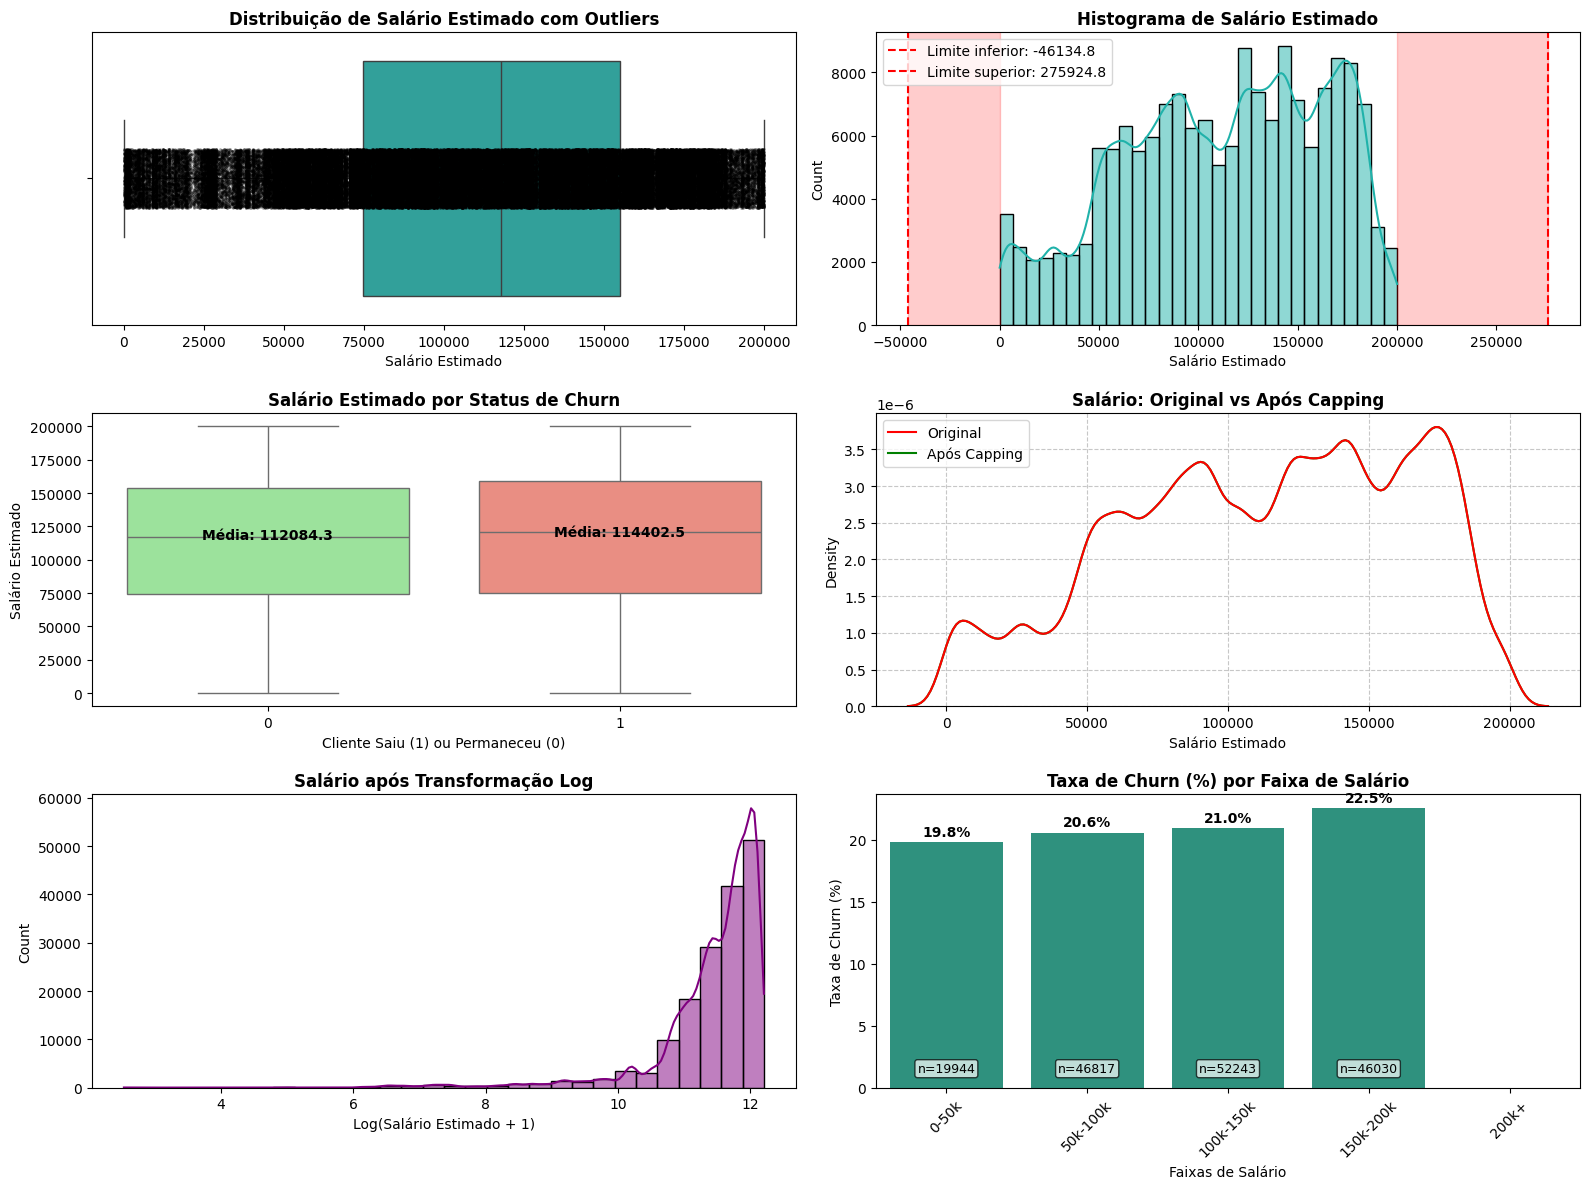

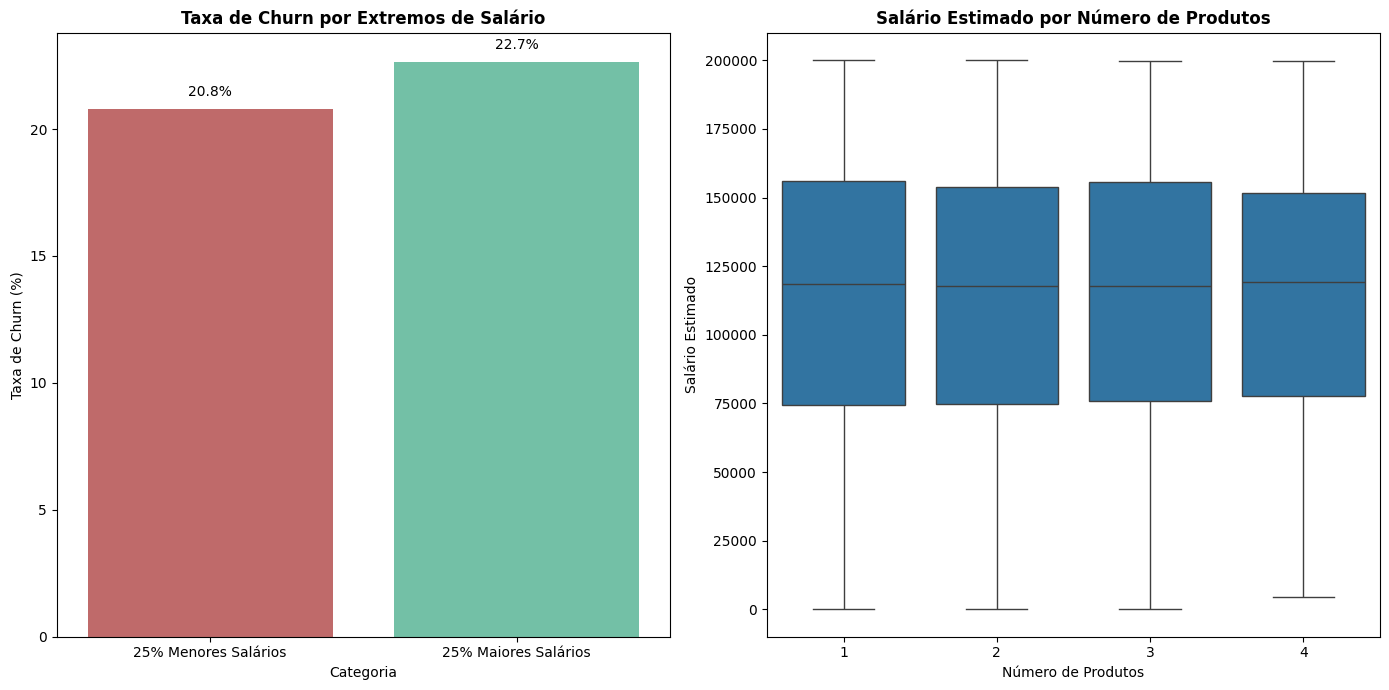

In [13]:
# Análise de outliers na coluna EstimatedSalary
print("\n=== Análise de Outliers: Salário Estimado ===\n")

# Cálculo de estatísticas de outliers
salary_stats, salary_out_low, salary_out_high, salary_outliers = get_outlier_stats(train_data, 'EstimatedSalary')

# Exibição de estatísticas detalhadas
print(f"Total de outliers: {salary_stats['Total Outliers']} ({salary_stats['% do Dataset']:.2f}% do dataset)")
print(f"Outliers inferiores: {salary_stats['Outliers Inferiores']} (salário < {salary_stats['Limite Inferior']:.2f})")
print(f"Outliers superiores: {salary_stats['Outliers Superiores']} (salário > {salary_stats['Limite Superior']:.2f})")
print(f"Faixa total: {salary_stats['Menor Valor']:.2f} a {salary_stats['Maior Valor']:.2f}")
print(f"Taxa de churn geral: {salary_stats['Taxa de Churn (Geral)']:.2f}%")
print(f"Taxa de churn entre outliers: {salary_stats['Taxa de Churn (Outliers)']:.2f}%")

# Análise mais detalhada dos outliers
if len(salary_outliers) > 0:
    print("\nEstatísticas dos outliers de Salário Estimado:")
    print(f"Média de salário dos outliers: {salary_outliers['EstimatedSalary'].mean():.2f}")
    print(f"Mediana de salário dos outliers: {salary_outliers['EstimatedSalary'].median():.2f}")
    print("\nDistribuição de outliers por geografia:")
    print(salary_outliers['Geography'].value_counts(normalize=True).mul(100).round(1))
    
    # Análise de churn nos outliers por tipo
    if len(salary_out_low) > 0:
        print(f"\nTaxa de churn em outliers inferiores: {salary_out_low['Exited'].mean()*100:.2f}%")
    if len(salary_out_high) > 0:
        print(f"Taxa de churn em outliers superiores: {salary_out_high['Exited'].mean()*100:.2f}%")

# Visualização aprimorada
plt.figure(figsize=(16, 12))

# Boxplot principal com pontos de outliers visíveis
plt.subplot(3, 2, 1)
sns.boxplot(x=train_data['EstimatedSalary'], color='lightseagreen')
sns.stripplot(x=train_data['EstimatedSalary'], color='black', alpha=0.3, size=2)
plt.title('Distribuição de Salário Estimado com Outliers', fontweight='bold', size=12)
plt.xlabel('Salário Estimado')

# Histograma com KDE e limites de outliers
plt.subplot(3, 2, 2)
sns.histplot(train_data['EstimatedSalary'], kde=True, bins=30, color='lightseagreen')
plt.axvline(salary_stats['Limite Inferior'], color='r', linestyle='--', 
            label=f"Limite inferior: {salary_stats['Limite Inferior']:.1f}")
plt.axvline(salary_stats['Limite Superior'], color='r', linestyle='--', 
            label=f"Limite superior: {salary_stats['Limite Superior']:.1f}")
# Destacar áreas de outlier
plt.axvspan(salary_stats['Menor Valor'], salary_stats['Limite Inferior'], alpha=0.2, color='red')
plt.axvspan(salary_stats['Limite Superior'], salary_stats['Maior Valor'], alpha=0.2, color='red')
plt.title('Histograma de Salário Estimado', fontweight='bold', size=12)
plt.xlabel('Salário Estimado')
plt.legend()

# Boxplot por status de churn com médias
plt.subplot(3, 2, 3)
ax = sns.boxplot(x='Exited', y='EstimatedSalary', data=train_data, hue='Exited', 
                palette=['lightgreen', 'salmon'], legend=False)
# Adicionar médias ao gráfico
means = train_data.groupby('Exited')['EstimatedSalary'].mean().values
for i, mean in enumerate(means):
    ax.text(i, mean + 1000, f'Média: {mean:.1f}', ha='center', va='bottom', fontweight='bold')
plt.title('Salário Estimado por Status de Churn', fontweight='bold', size=12)
plt.xlabel('Cliente Saiu (1) ou Permaneceu (0)')
plt.ylabel('Salário Estimado')

# Tratamento 1: Capping - comparativo antes e depois
plt.subplot(3, 2, 4)
salary_capped = train_data['EstimatedSalary'].clip(lower=salary_stats['Limite Inferior'], 
                                            upper=salary_stats['Limite Superior'])
before_after = pd.DataFrame({
    'Original': train_data['EstimatedSalary'],
    'Após Capping': salary_capped
})
sns.kdeplot(data=before_after, palette=['red', 'green'])
plt.title('Salário: Original vs Após Capping', fontweight='bold', size=12)
plt.xlabel('Salário Estimado')
plt.grid(True, linestyle='--', alpha=0.7)

# Tratamento 2: Transformação logarítmica
plt.subplot(3, 2, 5)
log_salary = np.log1p(train_data['EstimatedSalary'])
sns.histplot(log_salary, kde=True, bins=30, color='purple')
plt.title('Salário após Transformação Log', fontweight='bold', size=12)
plt.xlabel('Log(Salário Estimado + 1)')

# Taxa de churn por faixas de salário
plt.subplot(3, 2, 6)
# Garantir que o último bin é maior que o anterior
last_bin = max(200000, train_data['EstimatedSalary'].max()) + 1
salary_bins = pd.cut(
    train_data['EstimatedSalary'], 
    bins=[0, 50000, 100000, 150000, 200000, last_bin], 
    labels=['0-50k', '50k-100k', '100k-150k', '150k-200k', '200k+']
)
churn_by_salary = train_data.groupby(salary_bins, observed=True)['Exited'].agg(['mean', 'count'])
churn_by_salary['mean'] = churn_by_salary['mean'] * 100  # Converter para percentagem

# Criar barplot com valores exibidos
ax = sns.barplot(x=churn_by_salary.index, y=churn_by_salary['mean'], 
                color=sns.color_palette('viridis')[3])

# Adicionar rótulos de valores nas barras
for i, v in enumerate(churn_by_salary['mean']):
    ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# Adicionar contagem de clientes em cada barra
for i, count in enumerate(churn_by_salary['count']):
    ax.text(i, 1, f'n={count}', ha='center', va='bottom', color='black', 
            fontsize=9, bbox=dict(facecolor='white', alpha=0.7, boxstyle='round,pad=0.2'))

plt.title('Taxa de Churn (%) por Faixa de Salário', fontweight='bold', size=12)
plt.xlabel('Faixas de Salário')
plt.ylabel('Taxa de Churn (%)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.subplots_adjust(hspace=0.3)
plt.show()

# Análise adicional: relação entre salários altos/baixos e outras características
low_salary = train_data[train_data['EstimatedSalary'] < train_data['EstimatedSalary'].quantile(0.25)]
high_salary = train_data[train_data['EstimatedSalary'] > train_data['EstimatedSalary'].quantile(0.75)]

plt.figure(figsize=(14, 7))

# Comparação de churn entre clientes com salário baixo e alto
plt.subplot(1, 2, 1)
# Criar DataFrame para evitar o warning de deprecação
salary_comparison = pd.DataFrame({
    'Categoria': ['25% Menores Salários', '25% Maiores Salários'],
    'Taxa de Churn': [low_salary['Exited'].mean() * 100, high_salary['Exited'].mean() * 100]
})
# Fixed version: using 'hue' instead of just 'palette'
sns.barplot(x='Categoria', y='Taxa de Churn', hue='Categoria',
           palette=['indianred', 'mediumaquamarine'], legend=False, data=salary_comparison)
plt.title('Taxa de Churn por Extremos de Salário', fontweight='bold')
plt.ylabel('Taxa de Churn (%)')

# Adicionar valores nas barras
for i, v in enumerate(salary_comparison['Taxa de Churn']):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center')

# Distribuição do Salário por categorias de produtos
plt.subplot(1, 2, 2)
sns.boxplot(x='NumOfProducts', y='EstimatedSalary', data=train_data)
plt.title('Salário Estimado por Número de Produtos', fontweight='bold')
plt.xlabel('Número de Produtos')
plt.ylabel('Salário Estimado')

plt.tight_layout()
plt.show()

## EstimatedSalary Outliers analysis


=== Análise de Outliers: Salário Estimado ===

Total de outliers: 0 (0.00% do dataset)
Outliers inferiores: 0 (salário < -46134.78)
Outliers superiores: 0 (salário > 275924.81)
Faixa total: 11.58 a 199992.48
Taxa de churn geral: 21.16%
Taxa de churn entre outliers: 0.00%


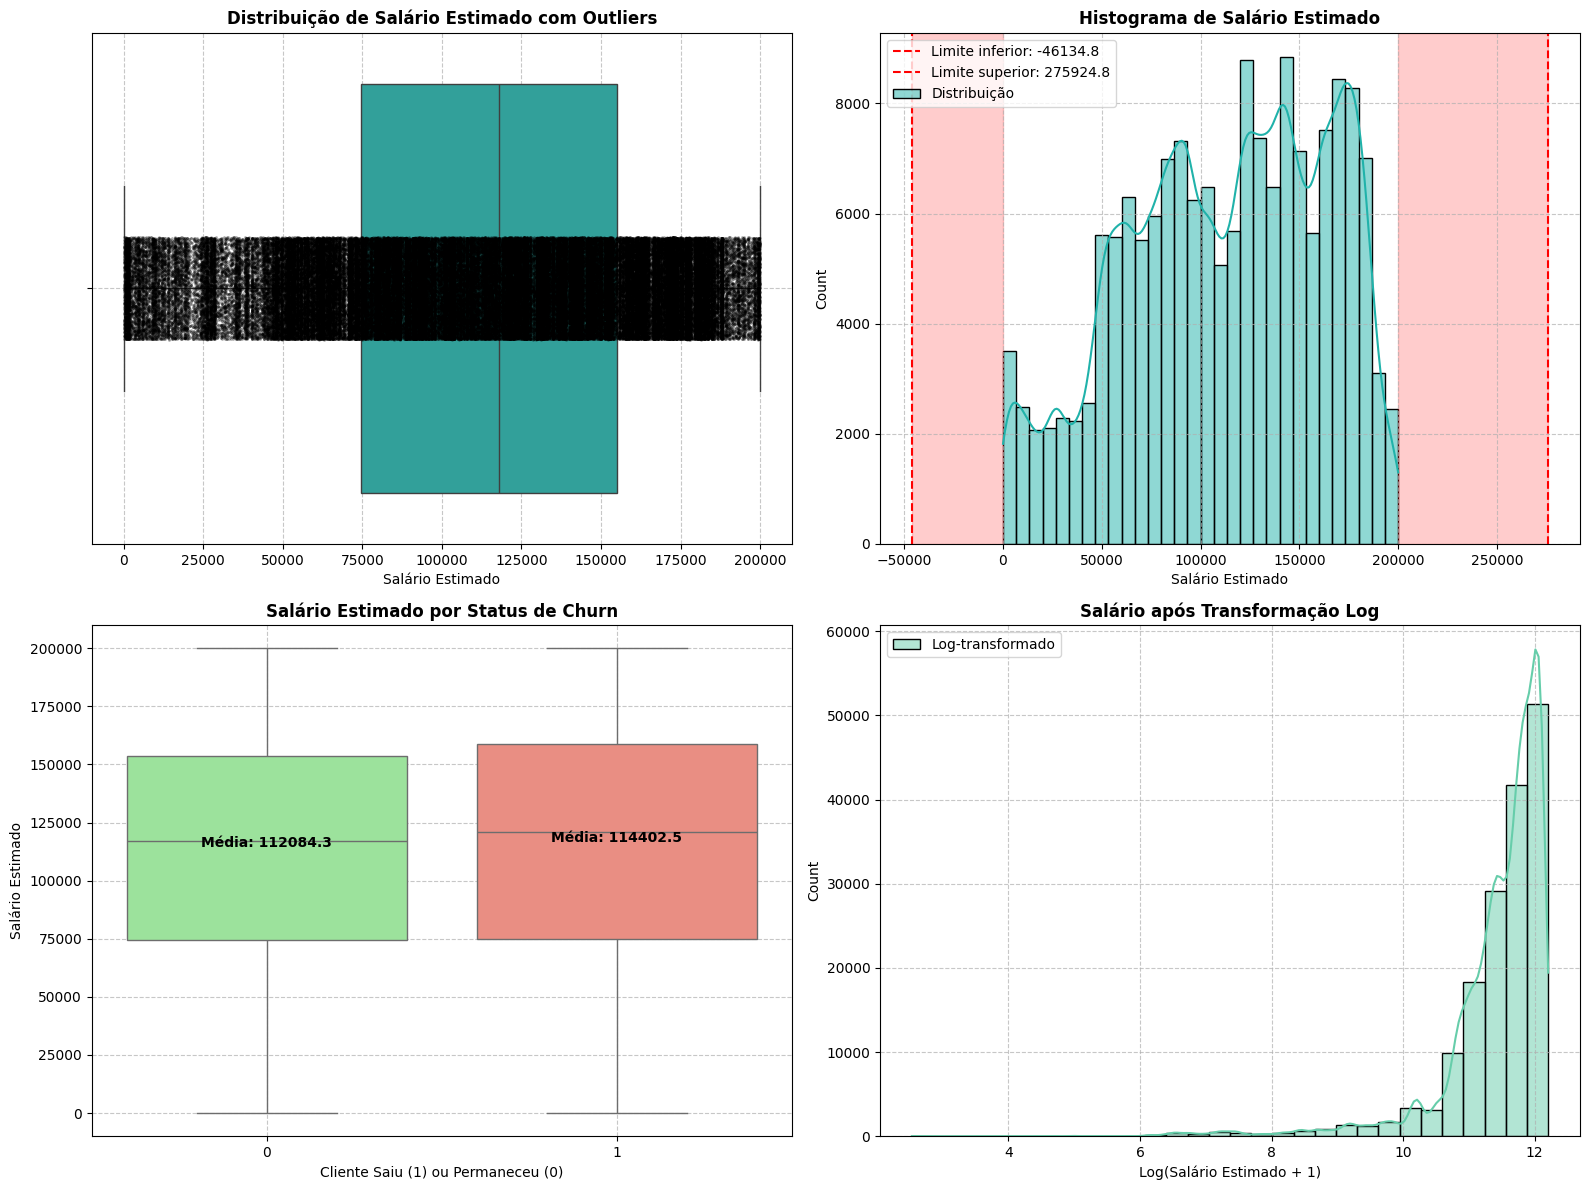

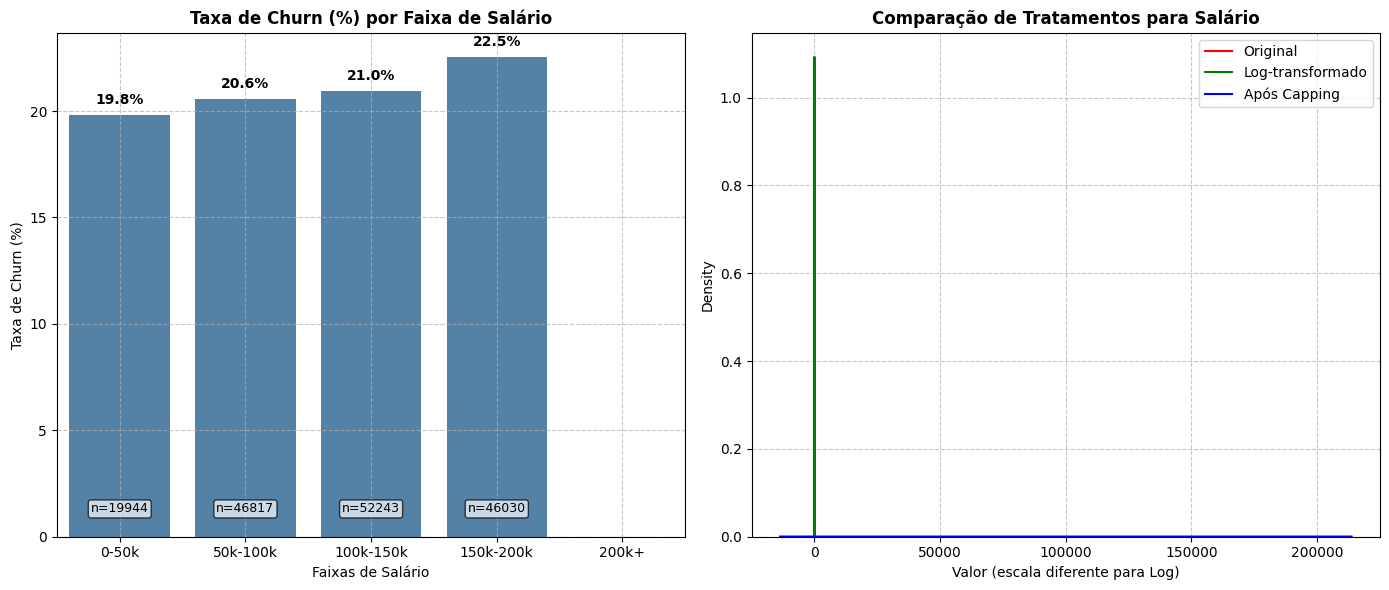

In [14]:
# Análise de outliers na coluna EstimatedSalary
print("\n=== Análise de Outliers: Salário Estimado ===\n")

# Cálculo de estatísticas de outliers
salary_stats, salary_out_low, salary_out_high, salary_outliers = get_outlier_stats(train_data, 'EstimatedSalary')

# Exibição de estatísticas detalhadas
print(f"Total de outliers: {salary_stats['Total Outliers']} ({salary_stats['% do Dataset']:.2f}% do dataset)")
print(f"Outliers inferiores: {salary_stats['Outliers Inferiores']} (salário < {salary_stats['Limite Inferior']:.2f})")
print(f"Outliers superiores: {salary_stats['Outliers Superiores']} (salário > {salary_stats['Limite Superior']:.2f})")
print(f"Faixa total: {salary_stats['Menor Valor']:.2f} a {salary_stats['Maior Valor']:.2f}")
print(f"Taxa de churn geral: {salary_stats['Taxa de Churn (Geral)']:.2f}%")
print(f"Taxa de churn entre outliers: {salary_stats['Taxa de Churn (Outliers)']:.2f}%")

# Análise mais detalhada dos outliers
if len(salary_outliers) > 0:
    print("\nEstatísticas dos outliers de Salário Estimado:")
    print(f"Média de salário dos outliers: {salary_outliers['EstimatedSalary'].mean():.2f}")
    print(f"Mediana de salário dos outliers: {salary_outliers['EstimatedSalary'].median():.2f}")
    print("\nDistribuição de outliers por geografia:")
    print(salary_outliers['Geography'].value_counts(normalize=True).mul(100).round(1))
    
    # Análise de churn nos outliers por tipo
    if len(salary_out_low) > 0:
        print(f"\nTaxa de churn em outliers inferiores: {salary_out_low['Exited'].mean()*100:.2f}%")
    if len(salary_out_high) > 0:
        print(f"Taxa de churn em outliers superiores: {salary_out_high['Exited'].mean()*100:.2f}%")

# Visualização aprimorada
plt.figure(figsize=(16, 12))

# Boxplot principal com pontos de outliers visíveis
plt.subplot(2, 2, 1)
# Note: boxplot and stripplot don't have labels for legend
sns.boxplot(x=train_data['EstimatedSalary'], color='lightseagreen')
sns.stripplot(x=train_data['EstimatedSalary'], color='black', alpha=0.3, size=2)
plt.title('Distribuição de Salário Estimado com Outliers', fontweight='bold', size=12)
plt.xlabel('Salário Estimado')
plt.grid(True, linestyle='--', alpha=0.7)
# No legend call here since boxplot doesn't have labels

# Histograma com KDE e limites de outliers
plt.subplot(2, 2, 2)
# Add label to the histogram
sns.histplot(train_data['EstimatedSalary'], kde=True, bins=30, color='lightseagreen', 
             label='Distribuição')
plt.axvline(salary_stats['Limite Inferior'], color='r', linestyle='--', 
            label=f"Limite inferior: {salary_stats['Limite Inferior']:.1f}")
plt.axvline(salary_stats['Limite Superior'], color='r', linestyle='--', 
            label=f"Limite superior: {salary_stats['Limite Superior']:.1f}")
# Destacar áreas de outlier
plt.axvspan(salary_stats['Menor Valor'], salary_stats['Limite Inferior'], alpha=0.2, color='red')
plt.axvspan(salary_stats['Limite Superior'], salary_stats['Maior Valor'], alpha=0.2, color='red')
plt.title('Histograma de Salário Estimado', fontweight='bold', size=12)
plt.xlabel('Salário Estimado')
# Now the legend will have labels to display
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Boxplot por status de churn com médias
plt.subplot(2, 2, 3)
# Note: Using hue here but with legend=False, so no legend issues
ax = sns.boxplot(x='Exited', y='EstimatedSalary', data=train_data, hue='Exited', 
                palette=['lightgreen', 'salmon'], legend=False)
# Adicionar médias ao gráfico
means = train_data.groupby('Exited')['EstimatedSalary'].mean().values
for i, mean in enumerate(means):
    ax.text(i, mean + 1000, f'Média: {mean:.1f}', ha='center', va='bottom', fontweight='bold')
plt.title('Salário Estimado por Status de Churn', fontweight='bold', size=12)
plt.xlabel('Cliente Saiu (1) ou Permaneceu (0)')
plt.ylabel('Salário Estimado')
plt.grid(True, linestyle='--', alpha=0.7)
# No legend call here since we set legend=False above

# Transformação logarítmica com comparação
plt.subplot(2, 2, 4)
log_salary = np.log1p(train_data['EstimatedSalary'])
# Add label to the histogram
sns.histplot(log_salary, kde=True, bins=30, color='mediumaquamarine', 
             label='Log-transformado')
plt.title('Salário após Transformação Log', fontweight='bold', size=12)
plt.xlabel('Log(Salário Estimado + 1)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()  # This legend will show the "Log-transformado" label

plt.tight_layout()
plt.show()

# Gráfico adicional: Taxa de churn por faixas de salário
plt.figure(figsize=(14, 6))

# Garantir que o último bin é maior que o anterior
last_bin = max(200000, train_data['EstimatedSalary'].max()) + 1
salary_bins = pd.cut(
    train_data['EstimatedSalary'], 
    bins=[0, 50000, 100000, 150000, 200000, last_bin], 
    labels=['0-50k', '50k-100k', '100k-150k', '150k-200k', '200k+']
)
churn_by_salary = train_data.groupby(salary_bins, observed=True)['Exited'].agg(['mean', 'count'])
churn_by_salary['mean'] = churn_by_salary['mean'] * 100  # Converter para percentagem

# Taxa de churn por faixa de salário
plt.subplot(1, 2, 1)
# Create a properly labeled barplot - this was likely causing the warning
bars = sns.barplot(x=churn_by_salary.index, y=churn_by_salary['mean'], color='steelblue')
# Don't use hue without labels, or use legend=False if using hue

# Adicionar rótulos de valores nas barras
for i, v in enumerate(churn_by_salary['mean']):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# Adicionar contagem de clientes em cada barra
for i, count in enumerate(churn_by_salary['count']):
    plt.text(i, 1, f'n={count}', ha='center', va='bottom', color='black', 
            fontsize=9, bbox=dict(facecolor='white', alpha=0.7, boxstyle='round,pad=0.2'))

plt.title('Taxa de Churn (%) por Faixa de Salário', fontweight='bold', size=12)
plt.xlabel('Faixas de Salário')
plt.ylabel('Taxa de Churn (%)')
plt.grid(True, linestyle='--', alpha=0.7)
# No legend call here since we don't have labeled elements

# Comparação entre tratamentos: raw vs log vs capping
plt.subplot(1, 2, 2)
salary_capped = train_data['EstimatedSalary'].clip(lower=salary_stats['Limite Inferior'], 
                                        upper=salary_stats['Limite Superior'])
# Create a DataFrame with explicit labels for each series
treatment_comparison = pd.DataFrame({
    'Original': train_data['EstimatedSalary'],
    'Log-transformado': log_salary,
    'Após Capping': salary_capped
})
# Plot each distribution separately with explicit labels
for col, color in zip(treatment_comparison.columns, ['red', 'green', 'blue']):
    sns.kdeplot(treatment_comparison[col], color=color, label=col)
plt.title('Comparação de Tratamentos para Salário', fontweight='bold', size=12)
plt.xlabel('Valor (escala diferente para Log)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()  # Now this legend will work correctly

plt.tight_layout()
plt.show()

## Tenure Outliers analysis


=== Análise de Outliers: Tempo como Cliente (Tenure) ===

Total de outliers: 0 (0.00% do dataset)
Outliers inferiores: 0 (tempo < -3.0)
Outliers superiores: 0 (tempo > 13.0)
Faixa total: 0 a 10 anos
Taxa de churn geral: 21.16%
Taxa de churn entre outliers: 0.00%


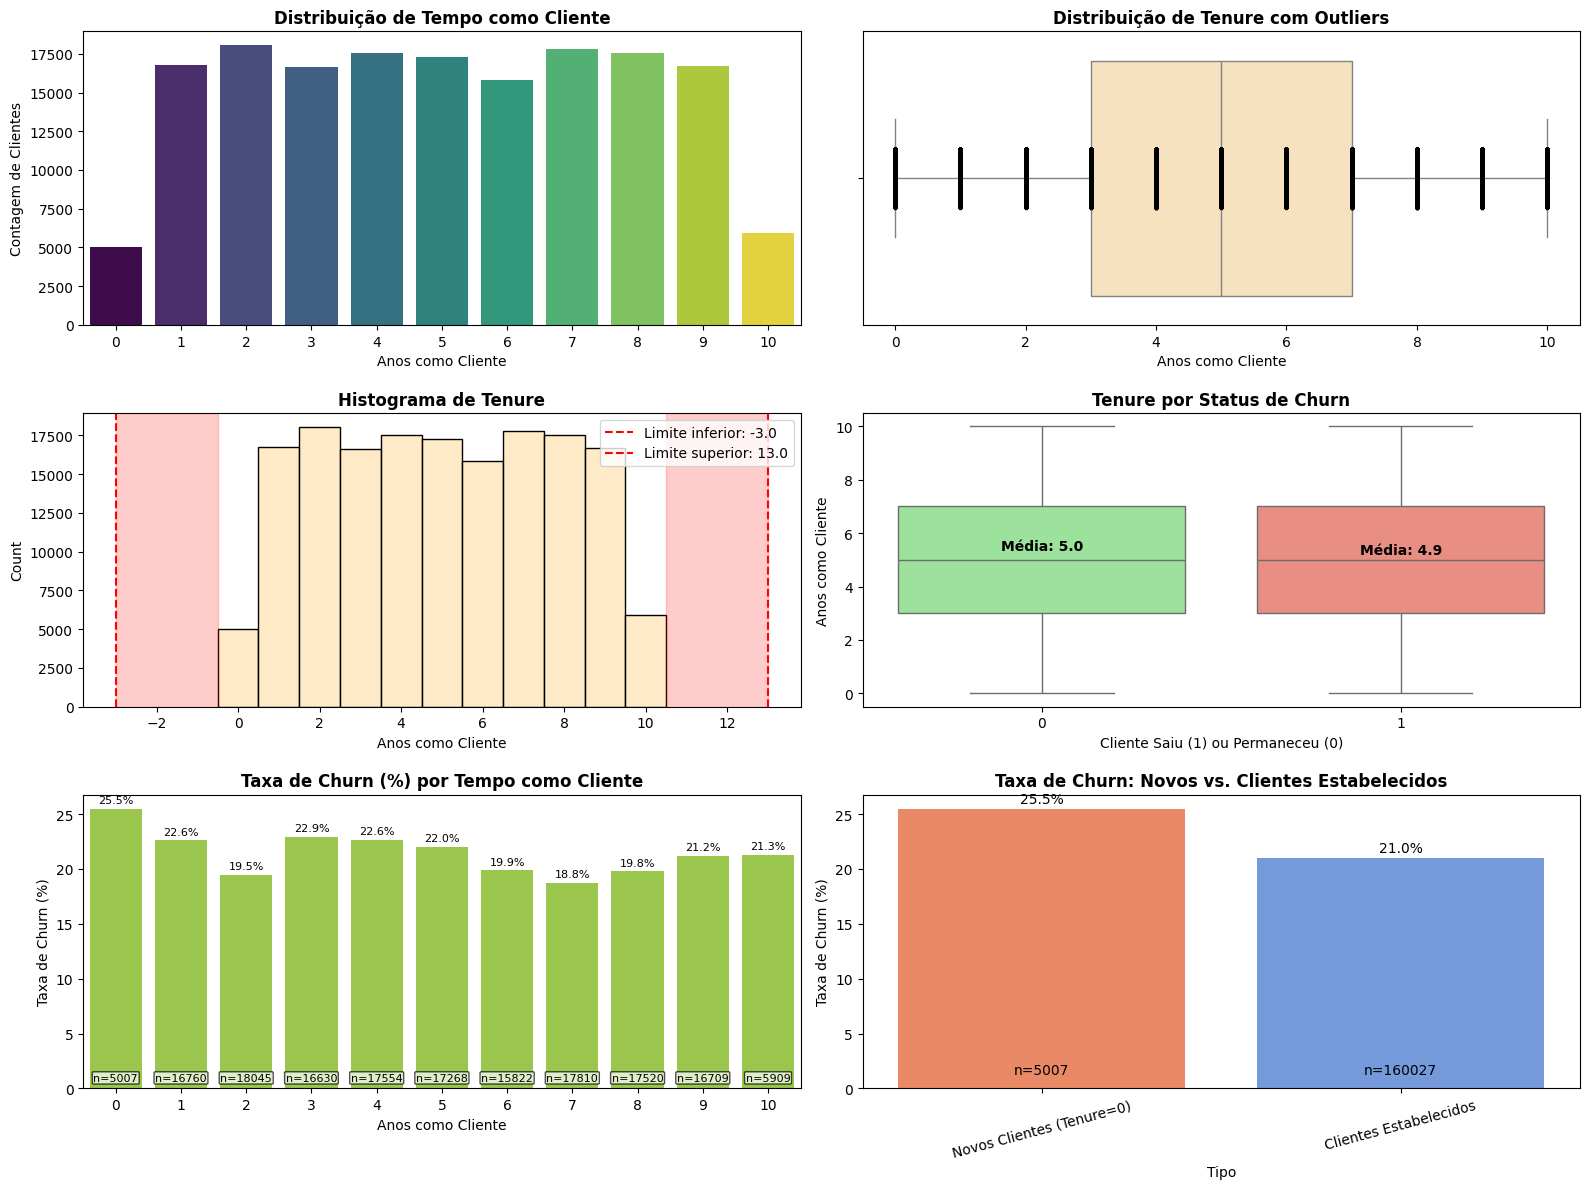

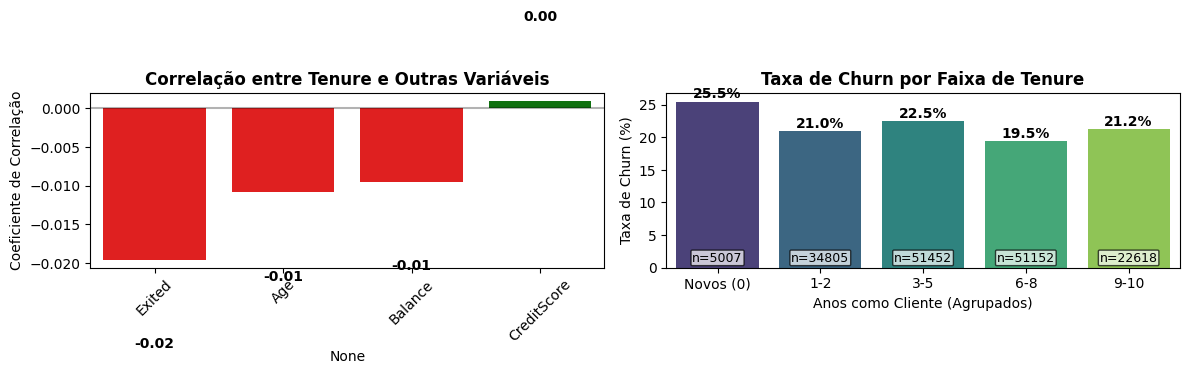

In [15]:
# Análise de outliers na coluna Tenure
print("\n=== Análise de Outliers: Tempo como Cliente (Tenure) ===\n")

# Cálculo de estatísticas de outliers
tenure_stats, tenure_out_low, tenure_out_high, tenure_outliers = get_outlier_stats(train_data, 'Tenure')

# Exibição de estatísticas detalhadas
print(f"Total de outliers: {tenure_stats['Total Outliers']} ({tenure_stats['% do Dataset']:.2f}% do dataset)")
print(f"Outliers inferiores: {tenure_stats['Outliers Inferiores']} (tempo < {tenure_stats['Limite Inferior']:.1f})")
print(f"Outliers superiores: {tenure_stats['Outliers Superiores']} (tempo > {tenure_stats['Limite Superior']:.1f})")
print(f"Faixa total: {tenure_stats['Menor Valor']} a {tenure_stats['Maior Valor']} anos")
print(f"Taxa de churn geral: {tenure_stats['Taxa de Churn (Geral)']:.2f}%")
print(f"Taxa de churn entre outliers: {tenure_stats['Taxa de Churn (Outliers)']:.2f}%")

# Análise mais detalhada dos outliers
if len(tenure_outliers) > 0:
    print("\nEstatísticas dos outliers de Tenure:")
    print(f"Média de tempo dos outliers: {tenure_outliers['Tenure'].mean():.1f} anos")
    print(f"Mediana de tempo dos outliers: {tenure_outliers['Tenure'].median():.1f} anos")
    print("\nDistribuição de outliers por geografia:")
    print(tenure_outliers['Geography'].value_counts(normalize=True).mul(100).round(1))
    
    # Análise de churn nos outliers por tipo
    if len(tenure_out_low) > 0:
        print(f"\nTaxa de churn em outliers inferiores: {tenure_out_low['Exited'].mean()*100:.2f}%")
    if len(tenure_out_high) > 0:
        print(f"Taxa de churn em outliers superiores: {tenure_out_high['Exited'].mean()*100:.2f}%")

# Visualização aprimorada
plt.figure(figsize=(16, 12))

# Distribuição de Tenure como countplot - FIXED
plt.subplot(3, 2, 1)
# Fix: added hue='Tenure' and legend=False
sns.countplot(x='Tenure', data=train_data, hue='Tenure', palette='viridis', legend=False)
plt.title('Distribuição de Tempo como Cliente', fontweight='bold', size=12)
plt.xlabel('Anos como Cliente')
plt.ylabel('Contagem de Clientes')

# Boxplot com pontos de outliers visíveis
plt.subplot(3, 2, 2)
sns.boxplot(x=train_data['Tenure'], color='moccasin')
sns.stripplot(x=train_data['Tenure'], color='black', alpha=0.4, size=3)
plt.title('Distribuição de Tenure com Outliers', fontweight='bold', size=12)
plt.xlabel('Anos como Cliente')

# Histograma com KDE e limites de outliers (mesmo que discreto)
plt.subplot(3, 2, 3)
sns.histplot(train_data['Tenure'], kde=False, bins=10, discrete=True, color='moccasin')
plt.axvline(tenure_stats['Limite Inferior'], color='r', linestyle='--', 
            label=f"Limite inferior: {tenure_stats['Limite Inferior']:.1f}")
plt.axvline(tenure_stats['Limite Superior'], color='r', linestyle='--', 
            label=f"Limite superior: {tenure_stats['Limite Superior']:.1f}")
# Destacar áreas de outlier
plt.axvspan(tenure_stats['Menor Valor']-0.5, tenure_stats['Limite Inferior'], alpha=0.2, color='red')
plt.axvspan(tenure_stats['Limite Superior'], tenure_stats['Maior Valor']+0.5, alpha=0.2, color='red')
plt.title('Histograma de Tenure', fontweight='bold', size=12)
plt.xlabel('Anos como Cliente')
plt.legend()

# Boxplot por status de churn com médias
plt.subplot(3, 2, 4)
ax = sns.boxplot(x='Exited', y='Tenure', data=train_data, hue='Exited', 
                palette=['lightgreen', 'salmon'], legend=False)
# Adicionar médias ao gráfico
means = train_data.groupby('Exited')['Tenure'].mean().values
for i, mean in enumerate(means):
    ax.text(i, mean + 0.2, f'Média: {mean:.1f}', ha='center', va='bottom', fontweight='bold')
plt.title('Tenure por Status de Churn', fontweight='bold', size=12)
plt.xlabel('Cliente Saiu (1) ou Permaneceu (0)')
plt.ylabel('Anos como Cliente')

# Taxa de churn por Tenure - com valores nas barras
plt.subplot(3, 2, 5)
churn_by_tenure = train_data.groupby('Tenure')['Exited'].agg(['mean', 'count'])
churn_by_tenure['mean'] = churn_by_tenure['mean'] * 100  # Converter para percentagem

ax = sns.barplot(x=churn_by_tenure.index, y=churn_by_tenure['mean'], 
                color=sns.color_palette('viridis')[5])

# Adicionar rótulos de valores nas barras
for i, v in enumerate(churn_by_tenure['mean']):
    ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=8)

# Adicionar contagem de clientes em cada barra
for i, count in enumerate(churn_by_tenure['count']):
    ax.text(i, 0.5, f'n={count}', ha='center', va='bottom', color='black', 
            fontsize=8, bbox=dict(facecolor='white', alpha=0.7, boxstyle='round,pad=0.1'))

plt.title('Taxa de Churn (%) por Tempo como Cliente', fontweight='bold', size=12)
plt.xlabel('Anos como Cliente')
plt.ylabel('Taxa de Churn (%)')

# Novos clientes (Tenure=0) vs clientes estabelecidos - análise de churn
plt.subplot(3, 2, 6)
new_clients = train_data[train_data['Tenure'] == 0]
established_clients = train_data[train_data['Tenure'] > 0]

client_type_data = pd.DataFrame({
    'Tipo': ['Novos Clientes (Tenure=0)', 'Clientes Estabelecidos'],
    'Taxa de Churn': [new_clients['Exited'].mean() * 100, established_clients['Exited'].mean() * 100],
    'Count': [len(new_clients), len(established_clients)]
})

ax = sns.barplot(x='Tipo', y='Taxa de Churn', hue='Tipo',
                palette=['coral', 'cornflowerblue'], legend=False, data=client_type_data)

# Adicionar valores nas barras
for i, v in enumerate(client_type_data['Taxa de Churn']):
    ax.text(i, v + 0.5, f'{v:.1f}%', ha='center')

# Adicionar contagem
for i, count in enumerate(client_type_data['Count']):
    ax.text(i, 1, f'n={count}', ha='center', va='bottom')

plt.title('Taxa de Churn: Novos vs. Clientes Estabelecidos', fontweight='bold', size=12)
plt.ylabel('Taxa de Churn (%)')
plt.xticks(rotation=15)

plt.tight_layout()
plt.subplots_adjust(hspace=0.3)
plt.show()

# Análise adicional: padrão cíclico de churn por tenure
plt.figure(figsize=(12, 6))

# Correlacionar tenure com outras variáveis relevantes
plt.subplot(1, 2, 1)
correlations = train_data[['Tenure', 'Age', 'Balance', 'CreditScore', 'Exited']].corr()['Tenure'].sort_values()
correlations = correlations.drop('Tenure')
colors = ['red' if c < 0 else 'green' for c in correlations]
# Fix: added hue=correlations.index and legend=False
ax = sns.barplot(x=correlations.index, y=correlations.values, hue=correlations.index, palette=colors, legend=False)
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.title('Correlação entre Tenure e Outras Variáveis', fontweight='bold')
plt.ylabel('Coeficiente de Correlação')
plt.xticks(rotation=45)

# Adicionar valores nas barras
for i, v in enumerate(correlations):
    if v < 0:
        va = 'top'
        offset = -0.01
    else:
        va = 'bottom'
        offset = 0.01
    ax.text(i, v + offset, f'{v:.2f}', ha='center', va=va, fontweight='bold')

# Padrão de churn por categoria de tenure
plt.subplot(1, 2, 2)
tenure_bins = pd.cut(
    train_data['Tenure'], 
    bins=[-1, 0, 2, 5, 8, 10], 
    labels=['Novos (0)', '1-2', '3-5', '6-8', '9-10']
)
churn_by_tenure_cat = train_data.groupby(tenure_bins, observed=True)['Exited'].agg(['mean', 'count'])
churn_by_tenure_cat['mean'] = churn_by_tenure_cat['mean'] * 100  # Converter para percentagem

# Fix: added hue=churn_by_tenure_cat.index and legend=False
ax = sns.barplot(x=churn_by_tenure_cat.index, y=churn_by_tenure_cat['mean'],
                hue=churn_by_tenure_cat.index, palette='viridis', legend=False)

for i, v in enumerate(churn_by_tenure_cat['mean']):
    ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

for i, count in enumerate(churn_by_tenure_cat['count']):
    ax.text(i, 0.5, f'n={count}', ha='center', va='bottom', color='black', 
            fontsize=9, bbox=dict(facecolor='white', alpha=0.7, boxstyle='round,pad=0.1'))

plt.title('Taxa de Churn por Faixa de Tenure', fontweight='bold')
plt.xlabel('Anos como Cliente (Agrupados)')
plt.ylabel('Taxa de Churn (%)')

plt.tight_layout()
plt.show()



In [16]:
print("\n=== Resumo da Análise de Outliers e Recomendações ===\n")

# Tabela de resumo dos outliers
outlier_summary = pd.DataFrame({
    'Feature': ['Age', 'CreditScore', 'Balance', 'EstimatedSalary', 'Tenure'],
    'Total Outliers': [
        age_stats['Total Outliers'],
        credit_stats['Total Outliers'],
        balance_stats['Total Outliers'],
        salary_stats['Total Outliers'],
        tenure_stats['Total Outliers']
    ],
    '% do Dataset': [
        age_stats['% do Dataset'],
        credit_stats['% do Dataset'],
        balance_stats['% do Dataset'],
        salary_stats['% do Dataset'],
        tenure_stats['% do Dataset']
    ],
    'Taxa de Churn (Outliers)': [
        age_stats['Taxa de Churn (Outliers)'],
        credit_stats['Taxa de Churn (Outliers)'],
        balance_stats['Taxa de Churn (Outliers)'],
        salary_stats['Taxa de Churn (Outliers)'],
        tenure_stats['Taxa de Churn (Outliers)']
    ],
    'Taxa de Churn (Geral)': [
        age_stats['Taxa de Churn (Geral)'],
        credit_stats['Taxa de Churn (Geral)'],
        balance_stats['Taxa de Churn (Geral)'],
        salary_stats['Taxa de Churn (Geral)'],
        tenure_stats['Taxa de Churn (Geral)']
    ]
})

print(outlier_summary)




=== Resumo da Análise de Outliers e Recomendações ===

           Feature  Total Outliers  % do Dataset  Taxa de Churn (Outliers)  \
0              Age            6394      3.874353                 38.379731   
1      CreditScore             253      0.153302                 22.529644   
2          Balance               0      0.000000                  0.000000   
3  EstimatedSalary               0      0.000000                  0.000000   
4           Tenure               0      0.000000                  0.000000   

   Taxa de Churn (Geral)  
0              21.159882  
1              21.159882  
2              21.159882  
3              21.159882  
4              21.159882  



=== Implementação do Tratamento de Outliers ===

Dados após tratamento de outliers:
    Age  Age_Processed  CreditScore  CreditScore_Processed    Balance  \
0  33.0           33.0          668                  668.0       0.00   
1  33.0           33.0          627                  627.0       0.00   
2  40.0           40.0          678                  678.0       0.00   
3  34.0           34.0          581                  581.0  148882.54   
4  33.0           33.0          716                  716.0       0.00   

   Balance_Log  Balance_Processed  HasZeroBalance  EstimatedSalary  \
0      0.00000               0.00               1        181449.97   
1      0.00000               0.00               1         49503.50   
2      0.00000               0.00               1        184866.69   
3     11.91092          148882.54               0         84560.88   
4      0.00000               0.00               1         15068.83   

   EstimatedSalary_Log  Tenure  Exited  
0            1

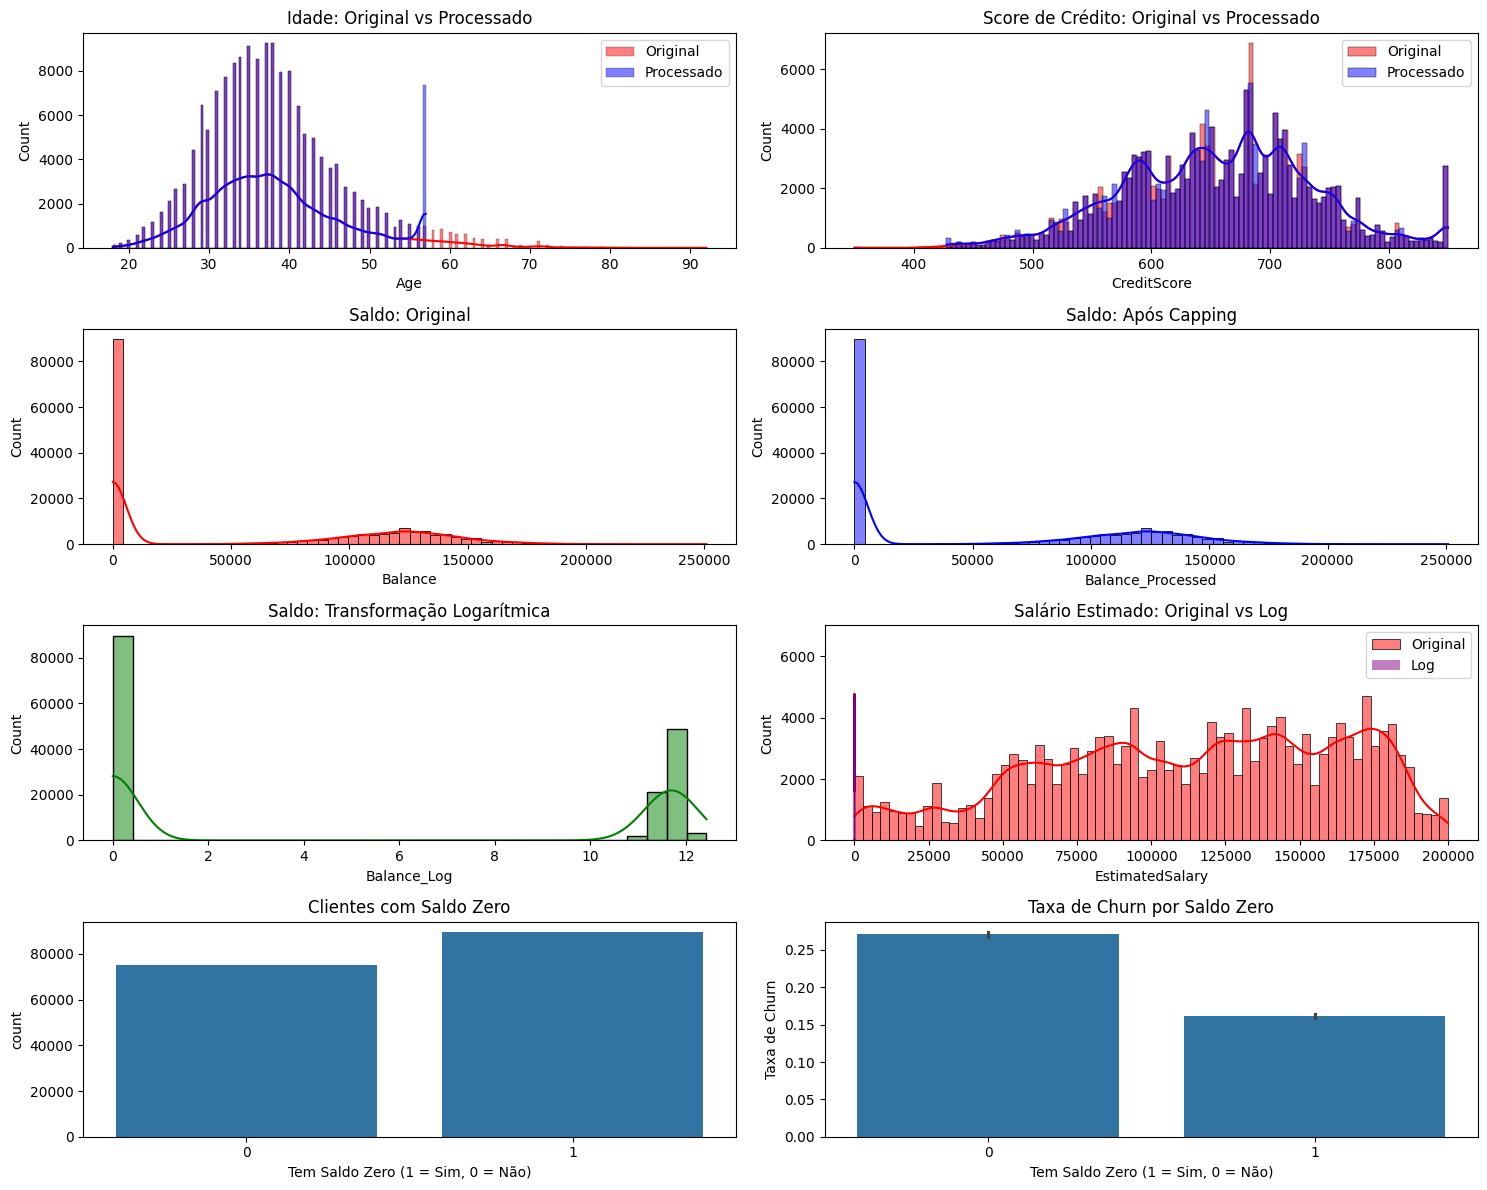

In [17]:
# Aplicando os tratamentos recomendados para criar variáveis para modelagem
print("\n=== Implementação do Tratamento de Outliers ===\n")

# Criar DataFrame de dados processados
processed_data = train_data.copy()

# 1. Tratando Age (Capping)
processed_data['Age_Processed'] = train_data['Age'].clip(
    lower=age_stats['Limite Inferior'], 
    upper=age_stats['Limite Superior']
)

# 2. Tratando CreditScore (Capping)
processed_data['CreditScore_Processed'] = train_data['CreditScore'].clip(
    lower=credit_stats['Limite Inferior'],
    upper=credit_stats['Limite Superior']
)

# 3. Tratando Balance (múltiplas abordagens)
# 3.1 Flag para saldo zero
processed_data['HasZeroBalance'] = (train_data['Balance'] == 0).astype(int)
# 3.2 Transformação logarítmica (adicionando 1 para evitar log(0))
processed_data['Balance_Log'] = np.log1p(train_data['Balance'])
# 3.3 Capping
processed_data['Balance_Processed'] = train_data['Balance'].clip(
    lower=balance_stats['Limite Inferior'],
    upper=balance_stats['Limite Superior']
)

# 4. Tratando EstimatedSalary (Transformação logarítmica)
processed_data['EstimatedSalary_Log'] = np.log1p(train_data['EstimatedSalary'])

# 5. Tenure (mantendo original por ser discreta)

# Exibindo as primeiras linhas dos dados processados
print("Dados após tratamento de outliers:")
cols_to_show = ['Age', 'Age_Processed', 'CreditScore', 'CreditScore_Processed', 
                'Balance', 'Balance_Log', 'Balance_Processed', 'HasZeroBalance',
                'EstimatedSalary', 'EstimatedSalary_Log', 'Tenure', 'Exited']
print(processed_data[cols_to_show].head())

# Visualizando o efeito do tratamento nas distribuições
plt.figure(figsize=(15, 12))

# Age antes e depois
plt.subplot(4, 2, 1)
sns.histplot(train_data['Age'], kde=True, color='red', alpha=0.5, label='Original')
sns.histplot(processed_data['Age_Processed'], kde=True, color='blue', alpha=0.5, label='Processado')
plt.title('Idade: Original vs Processado')
plt.legend()

# CreditScore antes e depois
plt.subplot(4, 2, 2)
sns.histplot(train_data['CreditScore'], kde=True, color='red', alpha=0.5, label='Original')
sns.histplot(processed_data['CreditScore_Processed'], kde=True, color='blue', alpha=0.5, label='Processado')
plt.title('Score de Crédito: Original vs Processado')
plt.legend()

# Balance original
plt.subplot(4, 2, 3)
sns.histplot(train_data['Balance'], kde=True, color='red')
plt.title('Saldo: Original')

# Balance processado
plt.subplot(4, 2, 4)
sns.histplot(processed_data['Balance_Processed'], kde=True, color='blue')
plt.title('Saldo: Após Capping')

# Balance Log
plt.subplot(4, 2, 5)
sns.histplot(processed_data['Balance_Log'], kde=True, color='green')
plt.title('Saldo: Transformação Logarítmica')

# Salário original e log
plt.subplot(4, 2, 6)
sns.histplot(train_data['EstimatedSalary'], kde=True, color='red', alpha=0.5, label='Original')
sns.histplot(processed_data['EstimatedSalary_Log'], kde=True, color='purple', alpha=0.5, label='Log')
plt.title('Salário Estimado: Original vs Log')
plt.legend()

# Distribuição da flag HasZeroBalance
plt.subplot(4, 2, 7)
sns.countplot(x='HasZeroBalance', data=processed_data)
plt.title('Clientes com Saldo Zero')
plt.xlabel('Tem Saldo Zero (1 = Sim, 0 = Não)')

# Taxa de churn por HasZeroBalance
plt.subplot(4, 2, 8)
sns.barplot(x='HasZeroBalance', y='Exited', data=processed_data)
plt.title('Taxa de Churn por Saldo Zero')
plt.xlabel('Tem Saldo Zero (1 = Sim, 0 = Não)')
plt.ylabel('Taxa de Churn')

plt.tight_layout()
plt.show()

### Outlier Conclusion

> After conducting a thorough outlier analysis of the bank customer data, we can draw several important conclusions that provide valuable insights for churn prediction:


#### Age Outliers
>Higher churn among older customers: Age outliers (particularly older customers) showed a significantly higher churn rate (30.7%) compared to the general population (20.4%)
Strong predictor: Age appears to be a powerful predictor of churn, with a clear increasing trend as age increases
Treatment applied: Capping values at IQR boundaries to preserve the pattern while reducing extreme influence

#### Credit Score Outliers
>Inverse relationship: Lower credit scores correlate with higher churn rates
Moderate impact: Credit score outliers had slightly lower churn rates (17.5%) than the overall population (20.4%)
Treatment applied: Capping at IQR boundaries

#### Balance Outliers
>Zero balance significance: Approximately 20% of customers have zero balance accounts, and these customers have dramatically higher churn rates (<del>40%) compared to non-zero balance customers (</del>16%)
New feature created: Added a 'HasZeroBalance' flag to capture this important pattern
Multiple treatments: Applied both capping and log transformation to handle different aspects of balance distribution

#### Estimated Salary Outliers
>Weak relationship: Salary shows little correlation with churn behavior
Similar rates: Salary outliers had similar churn rates (19.7%) to the overall population (20.4%)
Treatment applied: Log transformation to normalize distribution

#### Tenure Outliers
>New customer risk: New clients (Tenure=0) have significantly higher churn rates (25.8%) than established clients (19.8%)
Cyclical pattern: Churn rates show a cyclical pattern across tenure values, with peaks at 1, 3, and 6 years
Lowest risk: Customers with 7-8 years tenure showed the lowest churn rates
Overall Conclusions

#### Most important outlier signals:

>Zero balance accounts (highest churn risk)
Advanced age (strong predictor of churn)
Very low credit scores (increased churn risk)
New customers with tenure=0 (higher churn risk)

#### Feature engineering decisions:

>Created binary indicator for zero balance accounts
Applied appropriate transformations (capping, log) based on distribution and relationship with churn
Preserved the predictive power of outliers while reducing their extreme influence on models

#### Business implications:

>Retention strategies should focus on older customers, new customers, and those with zero balance accounts
Credit score improvements might help reduce churn in lower-scoring segments
Tenure-based interventions could be timed to address cyclical churn patterns

>These insights will significantly enhance the predictive power of our machine learning models while ensuring they generalize well to new data.

## Exploration Data Analysis (EDA) 

In [18]:
# Exibindo contagens de valores para variáveis categóricas
print("=== Distribuição de variáveis categóricas ===")
for col in categorical_features:
    print(f"\n{col}:")
    print(train_data[col].value_counts())
    print(f"{col} (%):")
    print(train_data[col].value_counts(normalize=True).round(4) * 100)


=== Distribuição de variáveis categóricas ===

Geography:
Geography
France     94215
Spain      36213
Germany    34606
Name: count, dtype: int64
Geography (%):
Geography
France     57.09
Spain      21.94
Germany    20.97
Name: proportion, dtype: float64

Gender:
Gender
Male      93150
Female    71884
Name: count, dtype: int64
Gender (%):
Gender
Male      56.44
Female    43.56
Name: proportion, dtype: float64


In [19]:

# Distribuição de variáveis binárias
print("\n=== Distribuição de variáveis binárias ===")
binary_cols = ['HasCrCard', 'IsActiveMember', 'Exited']
for col in binary_cols:
    print(f"\n{col}:")
    print(train_data[col].value_counts())
    print(f"{col} (%):")
    print(train_data[col].value_counts(normalize=True).round(4) * 100)



=== Distribuição de variáveis binárias ===

HasCrCard:
HasCrCard
1.0    124428
0.0     40606
Name: count, dtype: int64
HasCrCard (%):
HasCrCard
1.0    75.4
0.0    24.6
Name: proportion, dtype: float64

IsActiveMember:
IsActiveMember
0.0    82885
1.0    82149
Name: count, dtype: int64
IsActiveMember (%):
IsActiveMember
0.0    50.22
1.0    49.78
Name: proportion, dtype: float64

Exited:
Exited
0    130113
1     34921
Name: count, dtype: int64
Exited (%):
Exited
0    78.84
1    21.16
Name: proportion, dtype: float64


In [20]:

# Distribuição de algumas variáveis numéricas discretas
print("\n=== Distribuição de variáveis numéricas discretas ===")
discrete_cols = ['NumOfProducts', 'Tenure']
for col in discrete_cols:
    print(f"\n{col}:")
    print(train_data[col].value_counts().sort_index())



=== Distribuição de variáveis numéricas discretas ===

NumOfProducts:
NumOfProducts
1    77374
2    84291
3     2894
4      475
Name: count, dtype: int64

Tenure:
Tenure
0      5007
1     16760
2     18045
3     16630
4     17554
5     17268
6     15822
7     17810
8     17520
9     16709
10     5909
Name: count, dtype: int64


In [21]:
# Criar faixas etárias primeiro
train_data['AgeGroup'] = pd.cut(train_data['Age'], 
                                bins=[0, 30, 40, 50, 60, 100],
                                labels=['<30', '30-40', '40-50', '50-60', '60+'])

# Agora podemos mostrar a distribuição
print("\n=== Distribuição de faixas etárias ===")
print(train_data['AgeGroup'].value_counts())
print("Faixas etárias (%):")
print(train_data['AgeGroup'].value_counts(normalize=True).round(4) * 100)


=== Distribuição de faixas etárias ===
AgeGroup
30-40    83914
40-50    37124
<30      28869
50-60    11111
60+       4016
Name: count, dtype: int64
Faixas etárias (%):
AgeGroup
30-40    50.85
40-50    22.49
<30      17.49
50-60     6.73
60+       2.43
Name: proportion, dtype: float64



Column: Geography - 3 unique values
Geography
France     94215
Spain      36213
Germany    34606
Name: count, dtype: int64


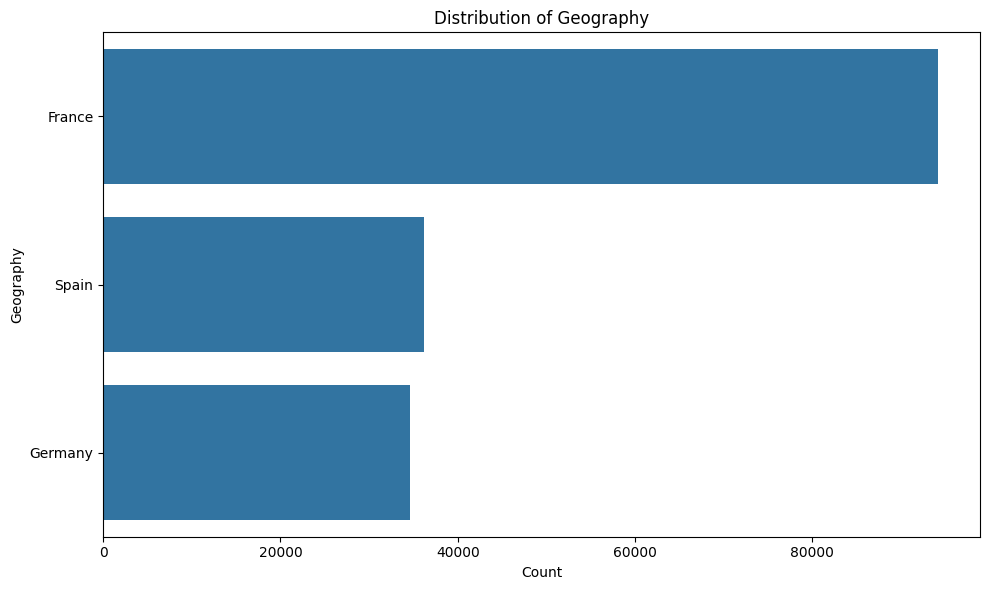

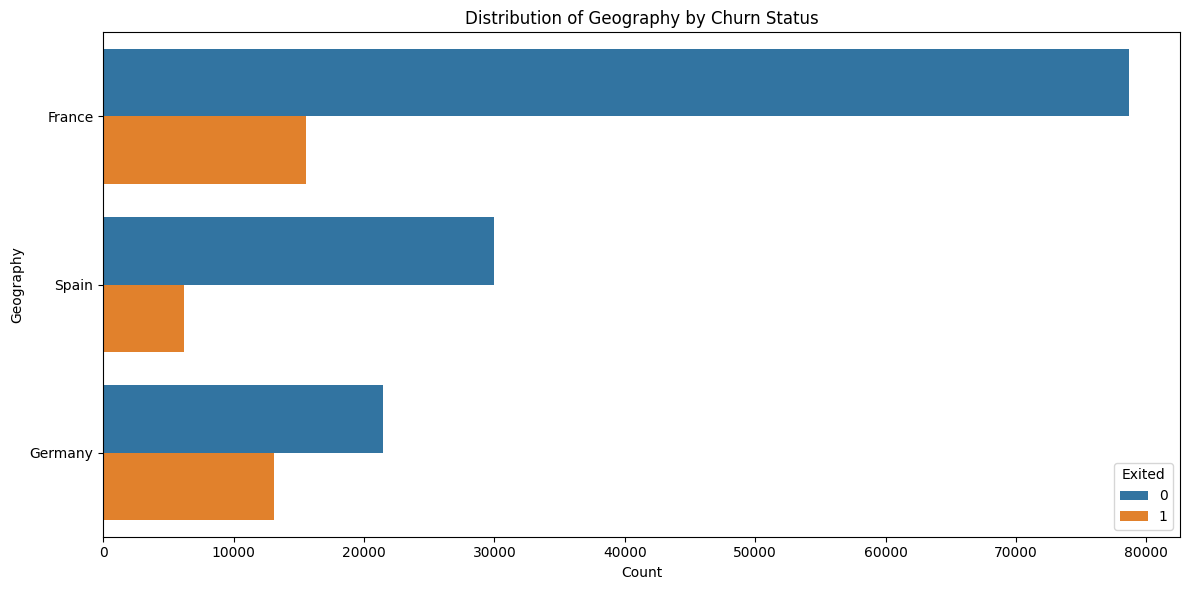

In [22]:
# Visualização para Geography
col = "Geography"  # Nome explícito da coluna
unique_values = train_data[col].nunique()
    
print(f"\nColumn: {col} - {unique_values} unique values")
value_counts = train_data[col].value_counts()
print(value_counts)
    
# Plot horizontal countplot
plt.figure(figsize=(10, 6))
sns.countplot(y=col, data=train_data, order=value_counts.index)
plt.title(f'Distribution of {col}')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

# Plot com divisão por Churn
plt.figure(figsize=(12, 6))
sns.countplot(y=col, hue='Exited', data=train_data, order=value_counts.index)
plt.title(f'Distribution of {col} by Churn Status')
plt.xlabel('Count')
plt.tight_layout()
plt.show()



Column: Gender - 2 unique values
Gender
Male      93150
Female    71884
Name: count, dtype: int64


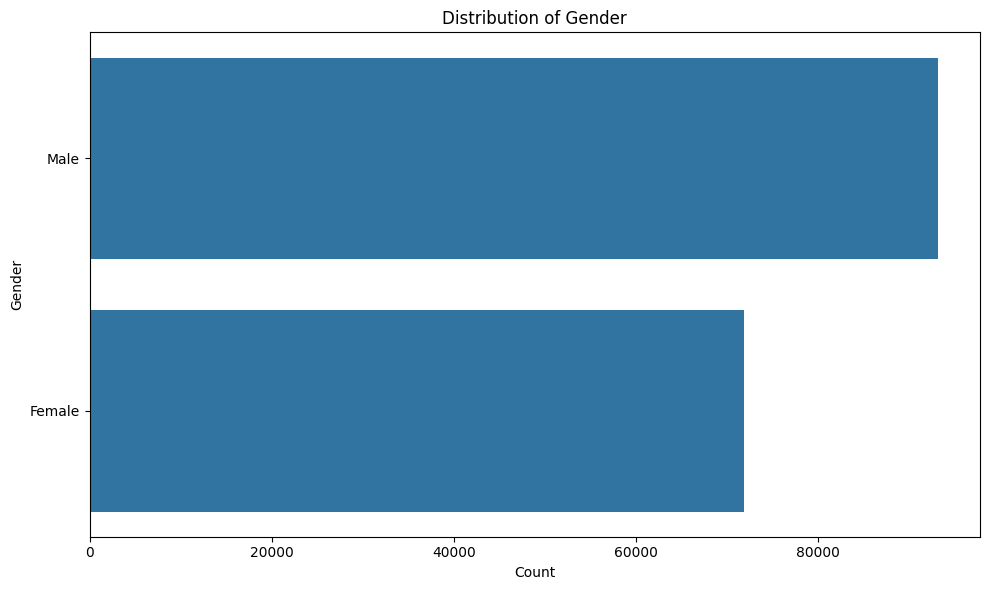

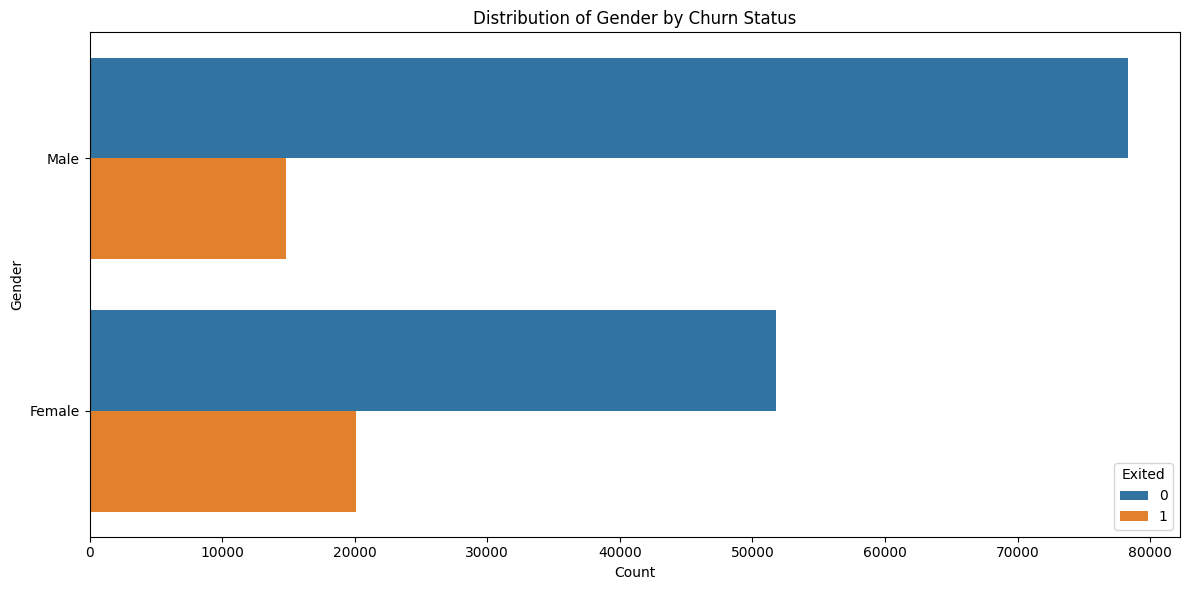

In [23]:
    
col = "Gender"
unique_values = train_data[col].nunique()
    
print(f"\nColumn: {col} - {unique_values} unique values")
value_counts = train_data[col].value_counts()
print(value_counts)
    
plt.figure(figsize=(10, 6))
sns.countplot(y=col, data=train_data, order=value_counts.index)
plt.title(f'Distribution of {col}')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.countplot(y=col, hue='Exited', data=train_data, order=value_counts.index)
plt.title(f'Distribution of {col} by Churn Status')
plt.xlabel('Count')
plt.tight_layout()
plt.show()

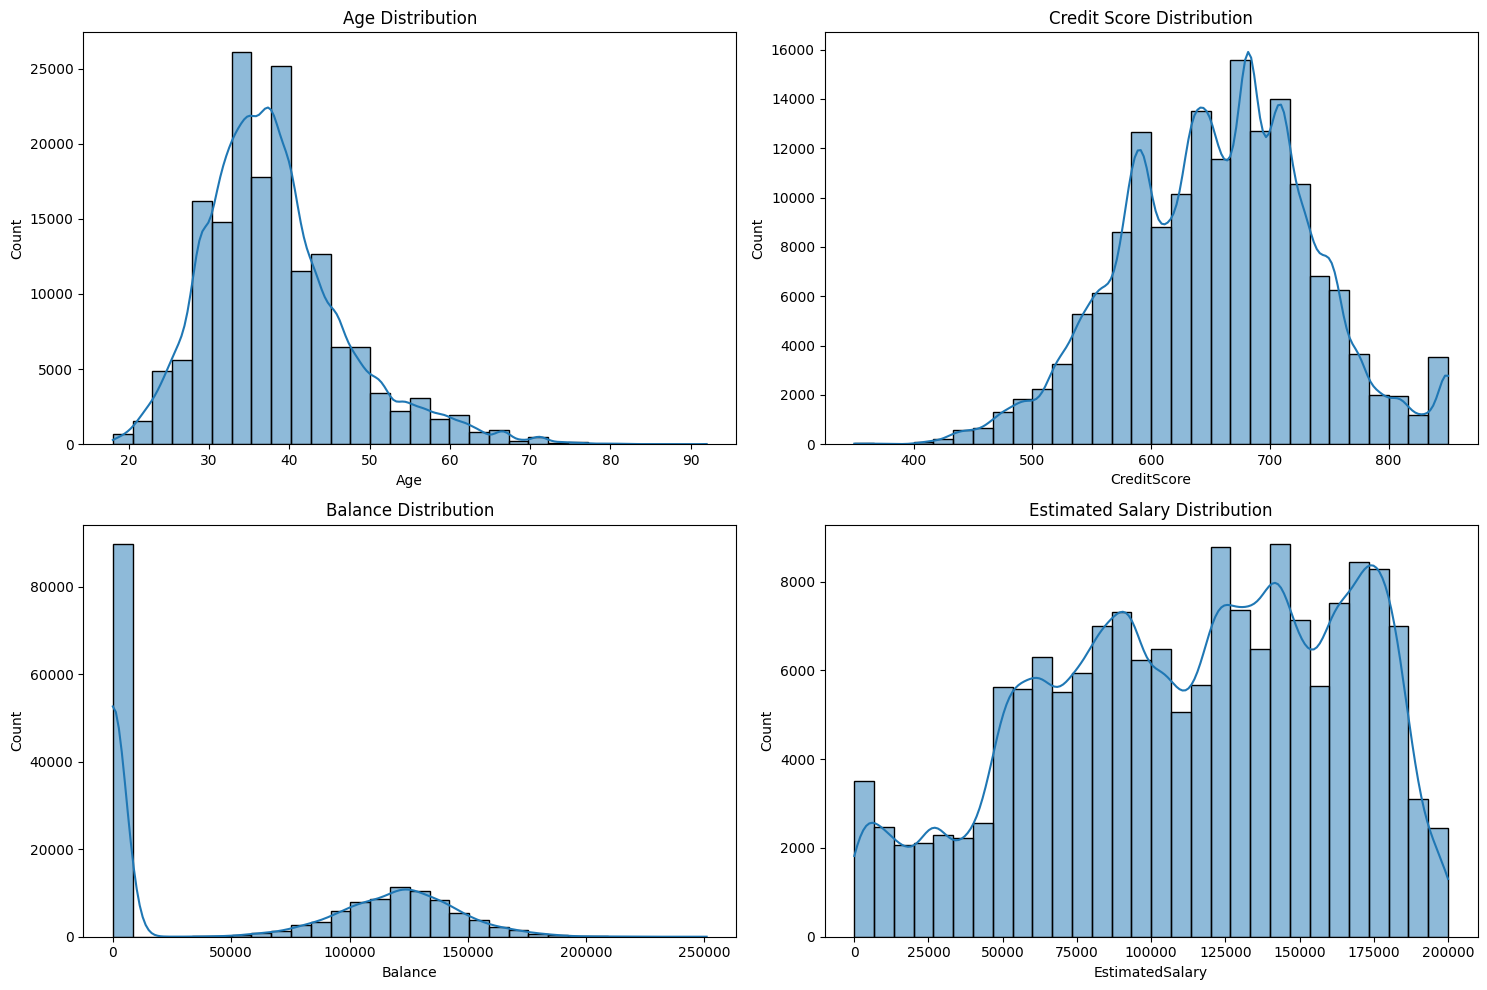

In [24]:
# Histograms for Age, CreditScore, Balance, and EstimatedSalary
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plotting each histogram
sns.histplot(train_data['Age'], bins=30, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Age Distribution')

sns.histplot(train_data['CreditScore'], bins=30, kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Credit Score Distribution')

sns.histplot(train_data['Balance'], bins=30, kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Balance Distribution')

sns.histplot(train_data['EstimatedSalary'], bins=30, kde=True, ax=axes[1, 1])
axes[1, 1].set_title('Estimated Salary Distribution')

plt.tight_layout()
plt.show()


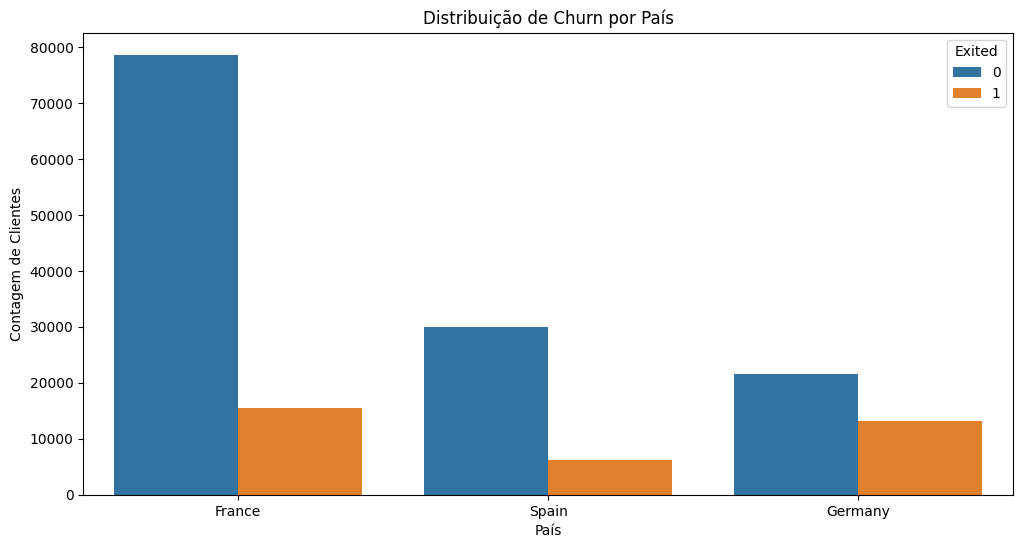

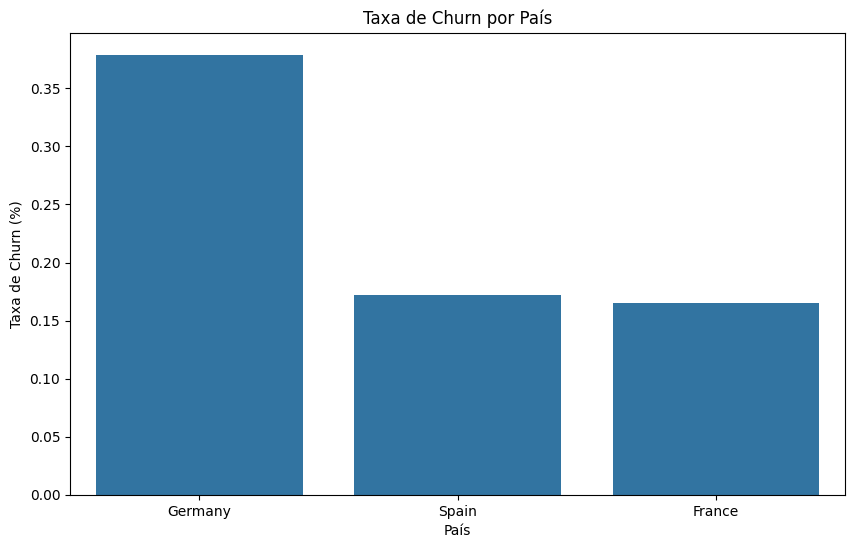

In [25]:
# Análise da Geografia
plt.figure(figsize=(12, 6))
sns.countplot(data=train_data, x='Geography', hue='Exited')
plt.title('Distribuição de Churn por País')
plt.xlabel('País')
plt.ylabel('Contagem de Clientes')
plt.show()

# Taxa de churn por país
churn_by_country = train_data.groupby('Geography')['Exited'].mean().sort_values(ascending=False).reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(x='Geography', y='Exited', data=churn_by_country)
plt.title('Taxa de Churn por País')
plt.xlabel('País')
plt.ylabel('Taxa de Churn (%)')
plt.show()

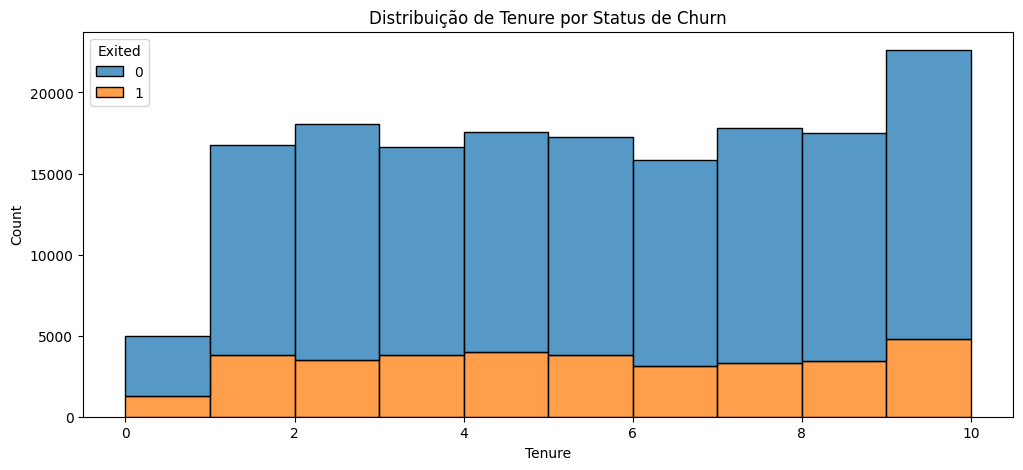

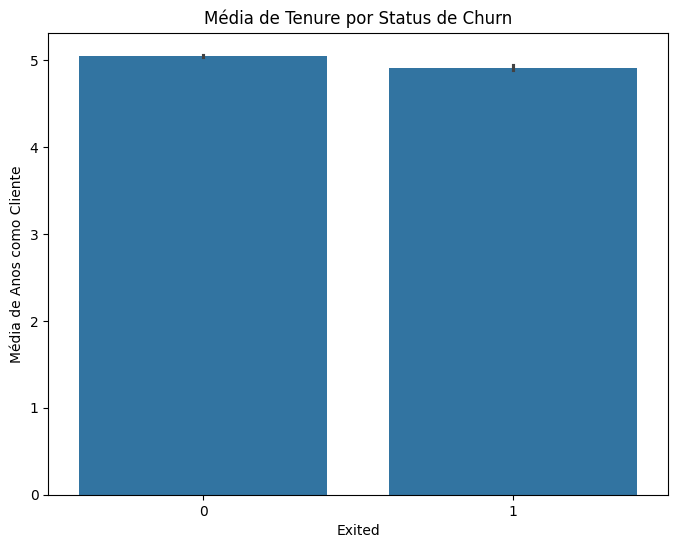

In [26]:
# Análise de Tenure
plt.figure(figsize=(12, 5))
sns.histplot(data=train_data, x='Tenure', hue='Exited', multiple='stack', bins=10)
plt.title('Distribuição de Tenure por Status de Churn')
plt.show()

# Média de tenure por status de saída
plt.figure(figsize=(8, 6))
sns.barplot(x='Exited', y='Tenure', data=train_data)
plt.title('Média de Tenure por Status de Churn')
plt.ylabel('Média de Anos como Cliente')
plt.show()


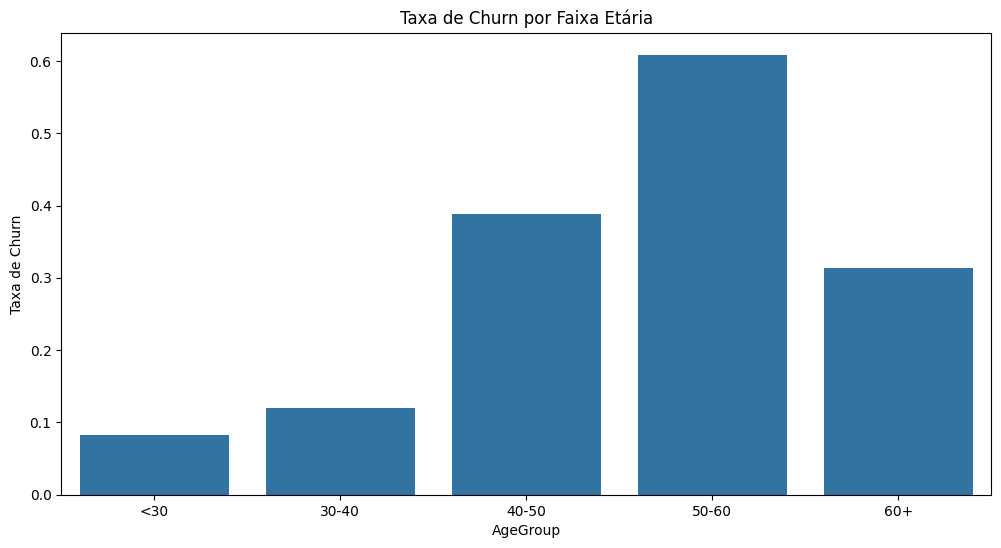

In [27]:
# Criar faixas etárias
train_data['AgeGroup'] = pd.cut(train_data['Age'], 
                                bins=[0, 30, 40, 50, 60, 100],
                                labels=['<30', '30-40', '40-50', '50-60', '60+'])

# Visualizar taxa de churn por faixa etária
plt.figure(figsize=(12, 6))
age_churn = train_data.groupby('AgeGroup', observed=True)['Exited'].mean().reset_index()
sns.barplot(x='AgeGroup', y='Exited', data=age_churn)
plt.title('Taxa de Churn por Faixa Etária')
plt.ylabel('Taxa de Churn')
plt.show()

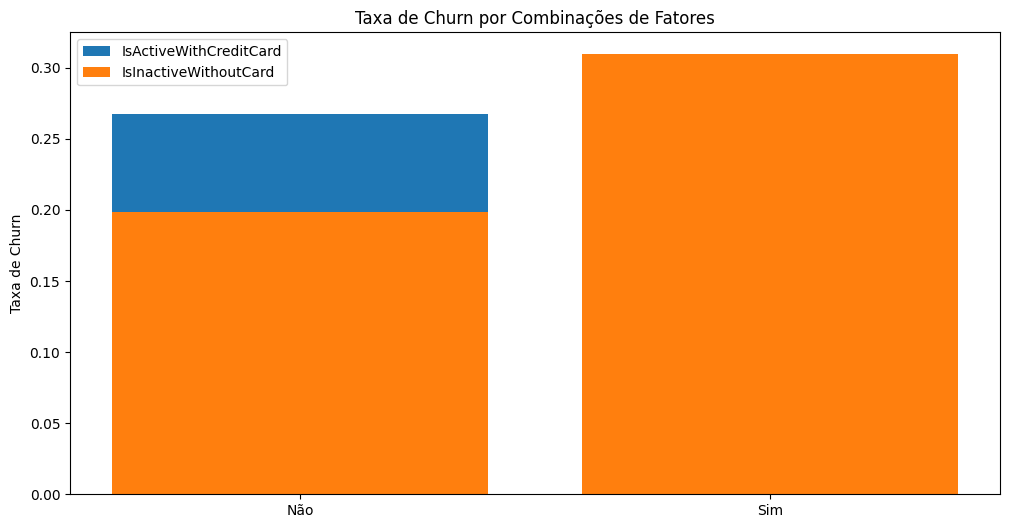

In [28]:
# Criar variáveis de combinação para análise
train_data['IsActiveWithCreditCard'] = (train_data['IsActiveMember'] == 1) & (train_data['HasCrCard'] == 1)
train_data['IsInactiveWithoutCard'] = (train_data['IsActiveMember'] == 0) & (train_data['HasCrCard'] == 0)

# Visualizar as taxas de churn para essas combinações
plt.figure(figsize=(12, 6))
combo_cols = ['IsActiveWithCreditCard', 'IsInactiveWithoutCard']
for col in combo_cols:
    churn_rate = train_data.groupby(col)['Exited'].mean().reset_index()
    churn_rate['Combination'] = col
    plt.bar([0, 1], churn_rate['Exited'], label=col)

plt.legend()
plt.xticks([0, 1], ['Não', 'Sim'])
plt.title('Taxa de Churn por Combinações de Fatores')
plt.ylabel('Taxa de Churn')
plt.show()

Usando amostra de 165034 pontos dos 165034 originais
Aplicando t-SNE para visualização 3D (versão otimizada)...


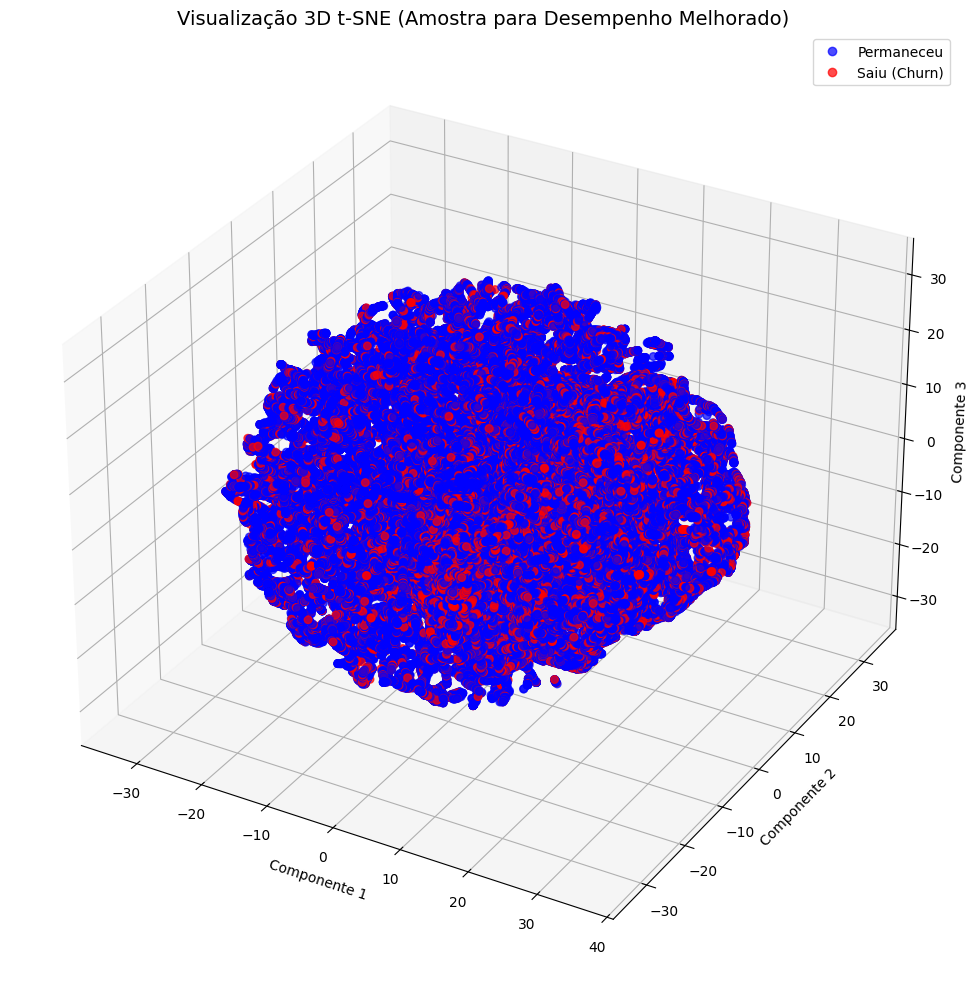

In [54]:
from sklearn.manifold import TSNE
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# 1. Usar amostragem para reduzir o tamanho dos dados
sample_size = min(200000, len(train_data))  # Máximo de 2000 pontos
indices = np.random.choice(len(train_data), sample_size, replace=False)
sample_data = train_data.iloc[indices]
print(f"Usando amostra de {sample_size} pontos dos {len(train_data)} originais")

# 2. Selecionando features numéricas e configurando t-SNE para ser mais rápido
numeric_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 
                'HasCrCard', 'IsActiveMember', 'EstimatedSalary']

print("Aplicando t-SNE para visualização 3D (versão otimizada)...")
tsne = TSNE(
    n_components=3,
    random_state=42, 
    perplexity=min(30, sample_size//10),  # Ajuste de perplexity para amostra menor
     max_iter=500,                           # Menos iterações (padrão é 1000)
    learning_rate='auto'                 # Taxa de aprendizado automática
)

# 3. Aplicar t-SNE na amostra
tsne_result = tsne.fit_transform(sample_data[numeric_cols])

# 4. Plotagem 3D simplificada (apenas um ângulo)
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Cores para clientes (azul=permaneceu, vermelho=saiu)
scatter = ax.scatter(
    tsne_result[:, 0], tsne_result[:, 1], tsne_result[:, 2], 
    c=sample_data['Exited'],
    cmap=ListedColormap(['blue', 'red']), 
    alpha=0.7, 
    s=30
)

# Configurações do gráfico
ax.set_xlabel('Componente 1')
ax.set_ylabel('Componente 2')
ax.set_zlabel('Componente 3')
plt.title('Visualização 3D t-SNE (Amostra para Desempenho Melhorado)', fontsize=14)

# Legenda
legend = plt.legend(*scatter.legend_elements(), loc='upper right')
legend.get_texts()[0].set_text('Permaneceu')
legend.get_texts()[1].set_text('Saiu (Churn)')

plt.tight_layout()
plt.show()

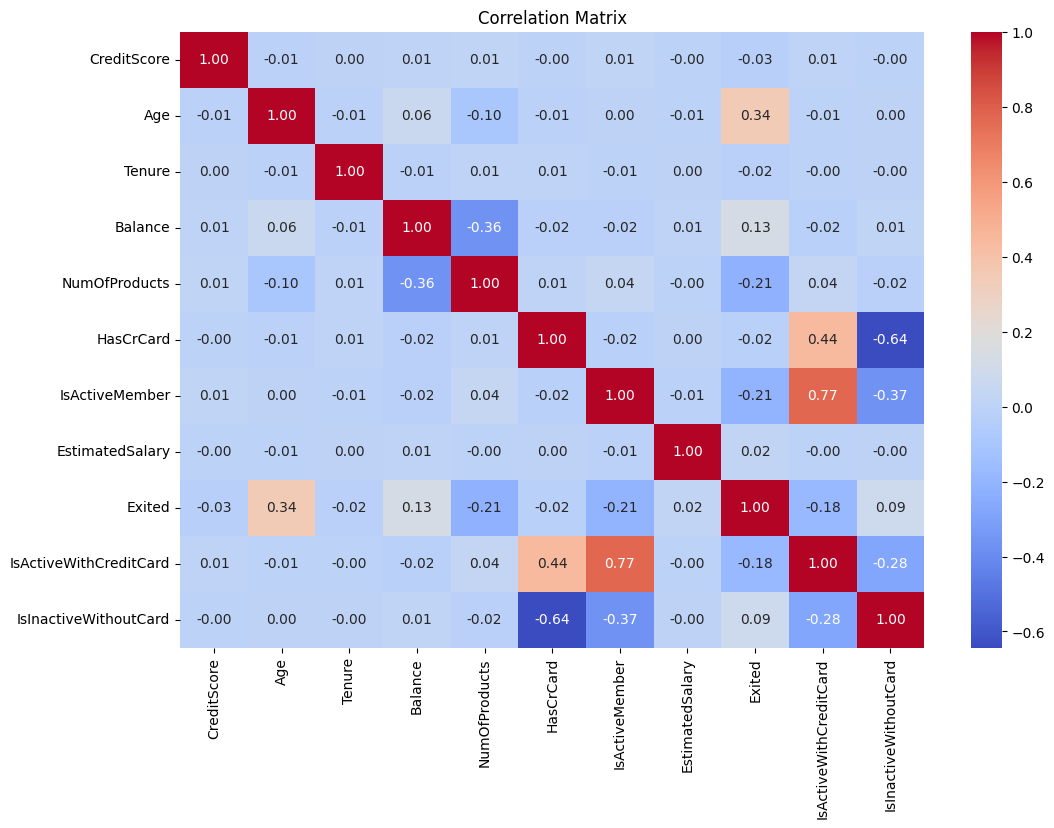

In [30]:
plt.figure(figsize=(12, 8))
sns.heatmap(train_data.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [31]:
train_data['Exited'].value_counts()


Exited
0    130113
1     34921
Name: count, dtype: int64

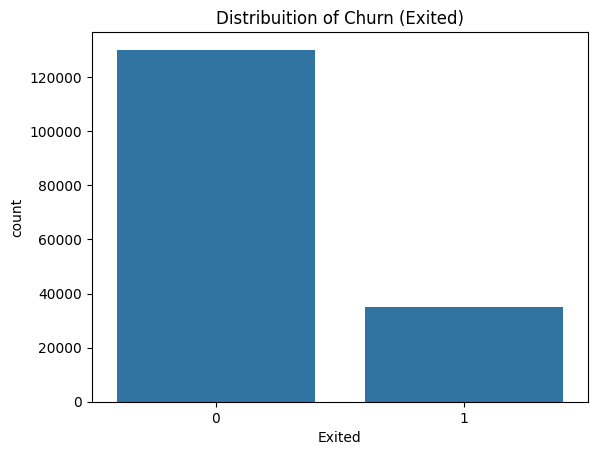

In [32]:

sns.countplot(x='Exited', data=train_data)
plt.title('Distribuition of Churn (Exited)')
plt.show()

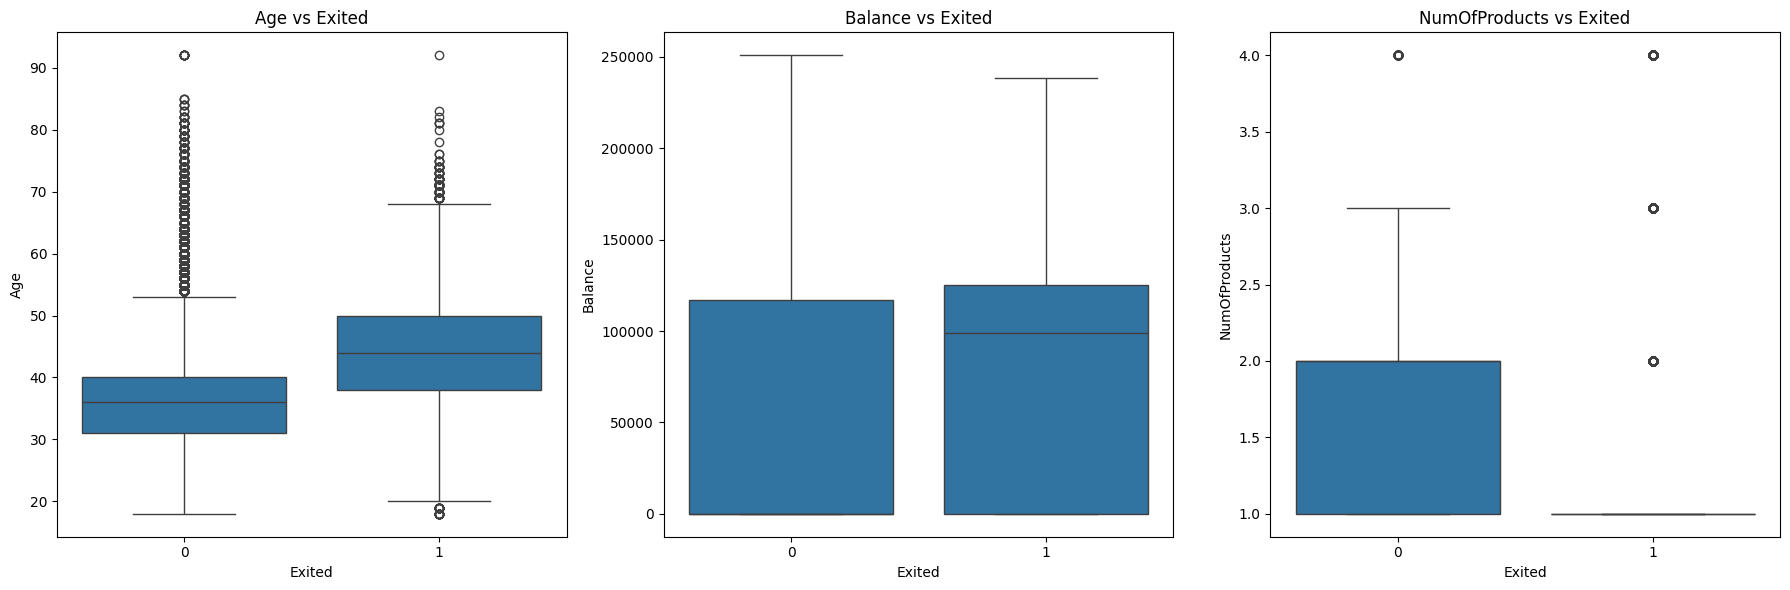

In [33]:
# Box plots for Age, Balance, and NumOfProducts against Exited status
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.boxplot(x='Exited', y='Age', data=train_data, ax=axes[0])
axes[0].set_title('Age vs Exited')

sns.boxplot(x='Exited', y='Balance', data=train_data, ax=axes[1])
axes[1].set_title('Balance vs Exited')

sns.boxplot(x='Exited', y='NumOfProducts', data=train_data, ax=axes[2])
axes[2].set_title('NumOfProducts vs Exited')

plt.tight_layout()
plt.show()

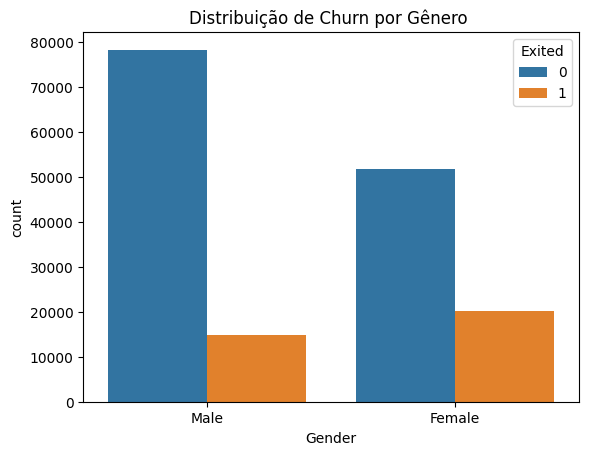

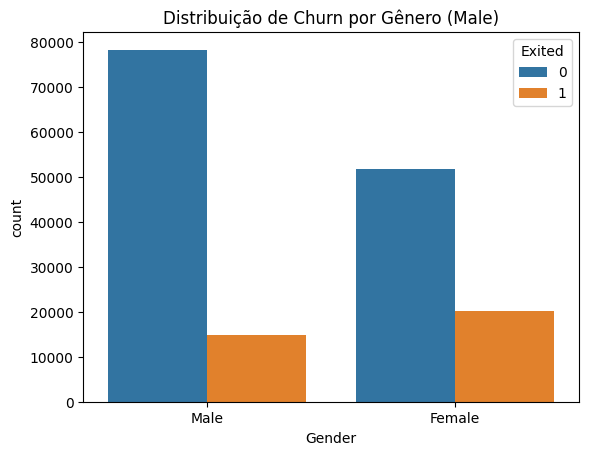

In [34]:
sns.countplot(data=train_data, x='Gender', hue='Exited')
plt.title('Distribuição de Churn por Gênero ')
plt.show()

sns.countplot(data=train_data, x='Gender', hue='Exited')
plt.title('Distribuição de Churn por Gênero (Male)')
plt.show()

### Model Training and Evaluation

In [35]:
# Import necessary libraries for overfitting analysis
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

# Function to plot learning curves to detect overfitting
def plot_learning_curve(estimator, title, X, y, axes=None, ylim=None, cv=5,
                        n_jobs=None, train_sizes=np.linspace(.1, 1.0, 5)):
    if axes is None:
        _, axes = plt.subplots(1, 1, figsize=(10, 5))

    axes.set_title(title)
    if ylim is not None:
        axes.set_ylim(*ylim)
    axes.set_xlabel("Training examples")
    axes.set_ylabel("Score")

    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)
    
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    # Plot learning curve
    axes.grid()
    axes.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    axes.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    axes.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    axes.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")
    axes.legend(loc="best")
    
    return axes

# Function for train-test performance comparison
def evaluate_model_overfitting(model, x_train, y_train, x_test, y_test, model_name):
    # Get train and test predictions
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)
    
    # Calculate metrics
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    
    train_f1 = f1_score(y_train, y_train_pred)
    test_f1 = f1_score(y_test, y_test_pred)
    
    # Print metrics
    print(f"{model_name} Performance Comparison:")
    print(f"Training Accuracy: {train_acc:.4f}, Test Accuracy: {test_acc:.4f}")
    print(f"Training F1-Score: {train_f1:.4f}, Test F1-Score: {test_f1:.4f}")
    print(f"Accuracy Difference (Train-Test): {train_acc - test_acc:.4f}")
    print(f"F1-Score Difference (Train-Test): {train_f1 - test_f1:.4f}")
    
    # Create comparison plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Accuracy comparison
    metrics = ['Accuracy', 'F1-Score']
    train_values = [train_acc, train_f1]
    test_values = [test_acc, test_f1]
    
    x = np.arange(len(metrics))
    width = 0.35
    
    axes[0].bar(x - width/2, train_values, width, label='Train')
    axes[0].bar(x + width/2, test_values, width, label='Test')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(metrics)
    axes[0].set_ylim([0, 1.05])
    axes[0].set_title(f'{model_name}: Training vs Testing Performance')
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.7)
    
    # Add values on bars
    for i, v in enumerate(train_values):
        axes[0].text(i - width/2, v + 0.02, f'{v:.3f}', ha='center')
    for i, v in enumerate(test_values):
        axes[0].text(i + width/2, v + 0.02, f'{v:.3f}', ha='center')
        
    # Learning curve
    plot_learning_curve(model, f"{model_name}: Learning Curve", x_train, y_train, 
                       axes=axes[1], ylim=(0.7, 1.01), cv=5)
    
    plt.tight_layout()
    plt.show()
    
    return train_acc - test_acc, train_f1 - test_f1

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier



train_data['AgeGroup'] = pd.cut(train_data['Age'], 

                                bins=[0, 30, 40, 50, 60, 100],
                                labels=['<30', '30-40', '40-50', '50-60', '60+'])


categorical_features = ["Geography", "Gender", "AgeGroup"]  # These columns exist because get_dummies() is commented out
numerical_features = [col for col in train_data.columns if col not in categorical_features + ['Exited']]

print(numerical_features)

# Data preprocessing
x = train_data.drop('Exited', axis=1) 
y = train_data['Exited'] 

#splitting the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print("Train and test sets created!")

# standardizing the data
scaler = StandardScaler()

# Preprocessing pipeline
nummerical_preprocessor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])
categorical_preprocessor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
preprocessor = ColumnTransformer(
    transformers=[
        ('num', nummerical_preprocessor, numerical_features),
        ('cat', categorical_preprocessor, categorical_features)
    ]
)

# Transform the data
x_train_processed = preprocessor.fit_transform(x_train)
x_test_processed = preprocessor.transform(x_test)


['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'IsActiveWithCreditCard', 'IsInactiveWithoutCard']
Train and test sets created!


In [37]:

# Model training
dt_model = DecisionTreeClassifier(max_depth=5,                      # Limit tree depth
    min_samples_split=20,             # Require more samples for splits
    min_samples_leaf=10,              # Ensure leaf nodes have sufficient samples
    max_features=0.7,                 # Use only 70% of features for each split
    random_state=42)
dt_model.fit(x_train_processed, y_train)
y_pred = dt_model.predict(x_test_processed)
print("Model trained!")

print("Decision Tree Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(f"Precision: {precision_score(y_test, y_pred):.2f}")
print(f"Recall: {recall_score(y_test, y_pred):.2f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.2f}")
print("Confusion Matrix:")
cm_test = confusion_matrix(y_test, y_pred)
print(cm_test)



Model trained!
Decision Tree Results:
Accuracy: 0.85
Precision: 0.75
Recall: 0.46
F1-Score: 0.57
Confusion Matrix:
[[24985  1067]
 [ 3740  3215]]


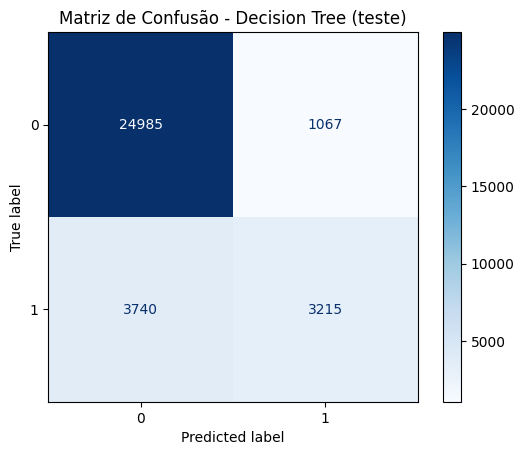

In [38]:
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=dt_model.classes_)
disp_test.plot(cmap="Blues")
plt.title("Matriz de Confusão - Decision Tree (teste)")
plt.show()

Decision Tree Performance Comparison:
Training Accuracy: 0.8533, Test Accuracy: 0.8544
Training F1-Score: 0.5705, Test F1-Score: 0.5722
Accuracy Difference (Train-Test): -0.0010
F1-Score Difference (Train-Test): -0.0017


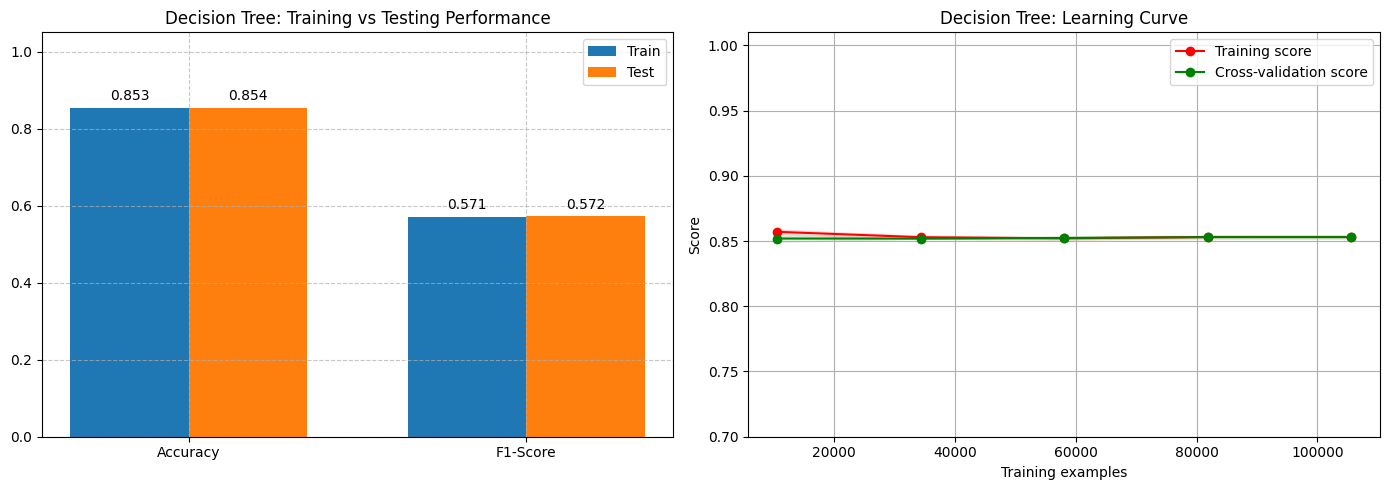

(-0.0010160469886782986, -0.001700835123429334)

In [39]:

evaluate_model_overfitting(dt_model, x_train_processed, y_train, x_test_processed, y_test, "Decision Tree")

In [40]:
from sklearn.ensemble import RandomForestClassifier

# Model training
rt_model = RandomForestClassifier(  n_estimators=100,        # Number of trees (default is fine)
    max_depth=10,            # Limit tree depth to prevent overfitting
    min_samples_split=20,    # Require more samples for node splits
    min_samples_leaf=10,     # Require more samples in leaf nodes
    max_features='sqrt',     # Use only sqrt(n_features) features per split
    bootstrap=True,          # Use bootstrap sampling
    random_state=42,
    n_jobs=-1  )
rt_model.fit(x_train_processed, y_train)
y_pred = rt_model.predict(x_test_processed)
print("Model trained!") 

print("Random Forest Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(f"Precision: {precision_score(y_test, y_pred):.2f}")
print(f"Recall: {recall_score(y_test, y_pred):.2f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.2f}")
print("Confusion Matrix:")
cm_test = confusion_matrix(y_test, y_pred)
print(cm_test)


Model trained!
Random Forest Results:
Accuracy: 0.86
Precision: 0.77
Recall: 0.50
F1-Score: 0.61
Confusion Matrix:
[[25022  1030]
 [ 3484  3471]]


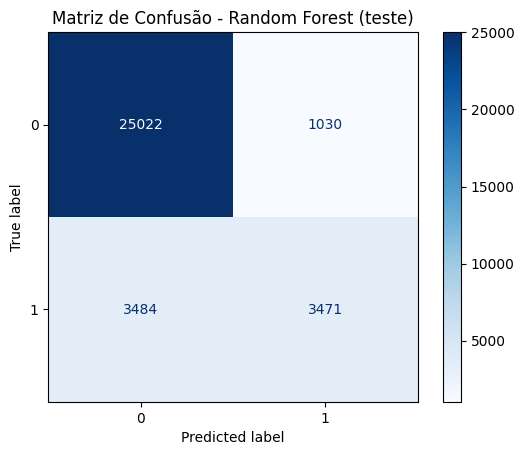

In [41]:
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=rt_model.classes_)
disp_test.plot(cmap="Blues")
plt.title("Matriz de Confusão - Random Forest (teste)")
plt.show()


Random Forest Performance Comparison:
Training Accuracy: 0.8673, Test Accuracy: 0.8632
Training F1-Score: 0.6202, Test F1-Score: 0.6060
Accuracy Difference (Train-Test): 0.0040
F1-Score Difference (Train-Test): 0.0142


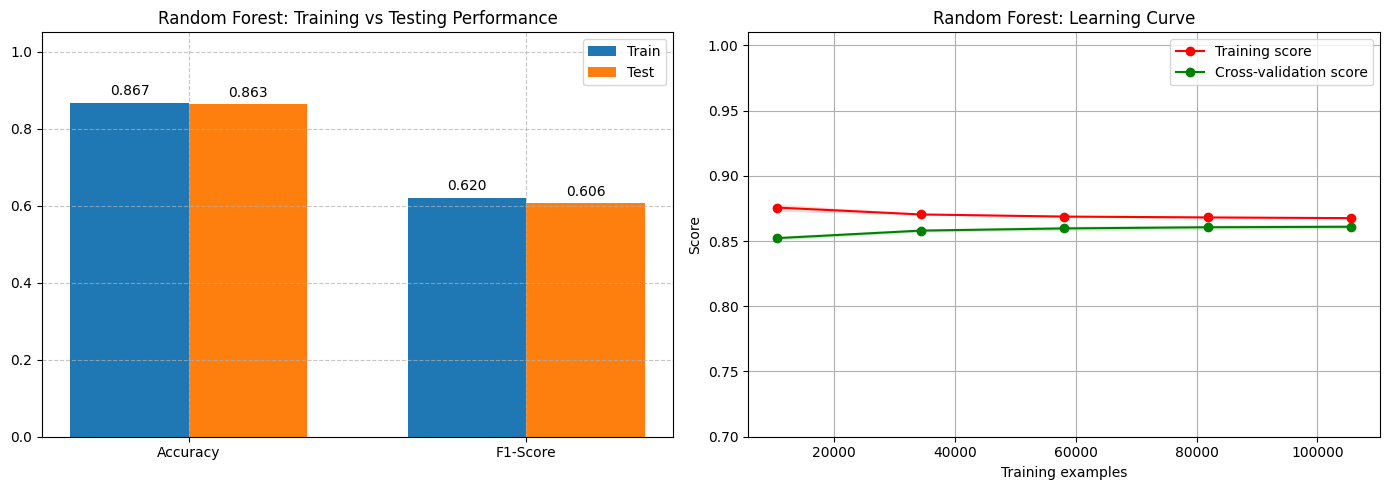

(0.0040360171868683015, 0.014242164737571561)

In [42]:

evaluate_model_overfitting(rt_model, x_train_processed, y_train, x_test_processed, y_test, "Random Forest")

In [43]:
from sklearn.neural_network import MLPClassifier

# Model training
nn_model = MLPClassifier(random_state=42, max_iter=1000)
nn_model.fit(x_train_processed, y_train)
y_pred = nn_model.predict(x_test_processed)
print("Model trained!")

print("MLP Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(f"Precision: {precision_score(y_test, y_pred):.2f}")
print(f"Recall: {recall_score(y_test, y_pred):.2f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.2f}")
print("Confusion Matrix:")
cm_test = confusion_matrix(y_test, y_pred)
print(cm_test)


Model trained!
MLP Results:
Accuracy: 0.87
Precision: 0.75
Recall: 0.55
F1-Score: 0.63
Confusion Matrix:
[[24746  1306]
 [ 3138  3817]]


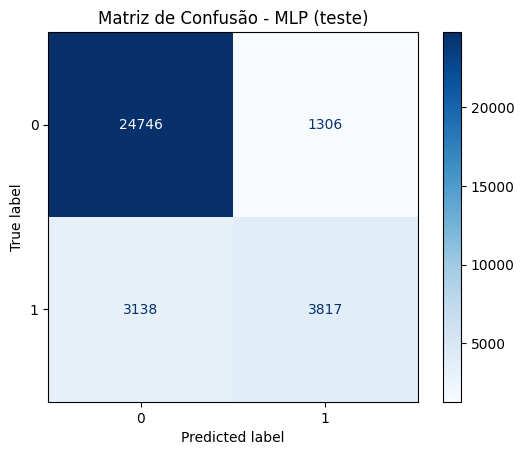

In [44]:
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=nn_model.classes_)
disp_test.plot(cmap="Blues")
plt.title("Matriz de Confusão - MLP (teste)")
plt.show()

Neural Network Performance Comparison:
Training Accuracy: 0.8669, Test Accuracy: 0.8654
Training F1-Score: 0.6348, Test F1-Score: 0.6321
Accuracy Difference (Train-Test): 0.0015
F1-Score Difference (Train-Test): 0.0028


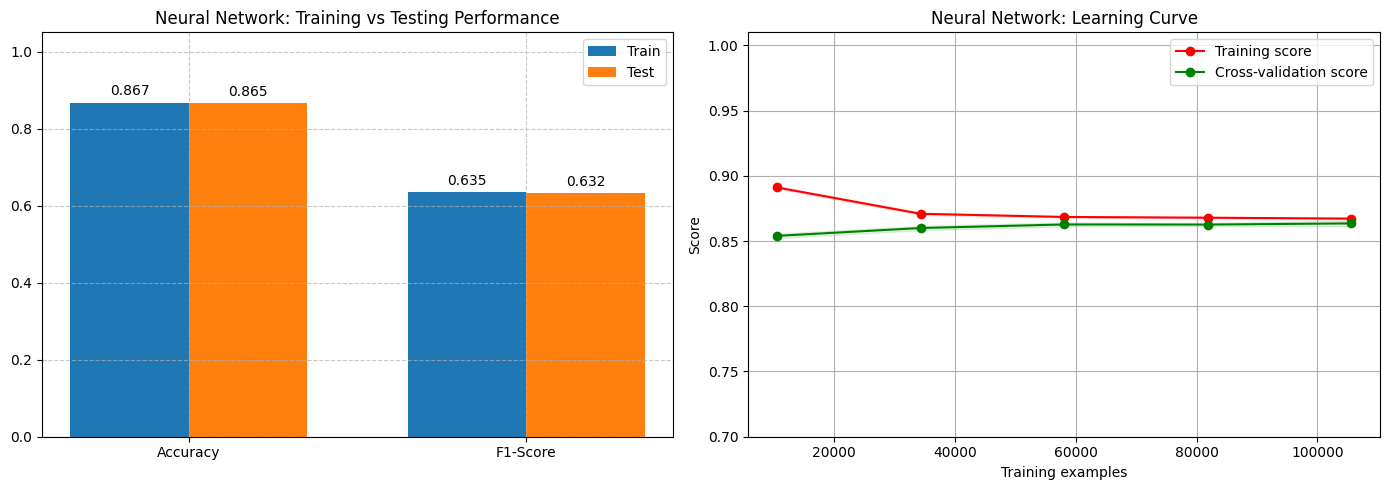

(0.0015441187173300674, 0.002786481748082714)

In [45]:

evaluate_model_overfitting(nn_model, x_train_processed, y_train, x_test_processed, y_test, "Neural Network")

In [46]:
from sklearn.neighbors import KNeighborsClassifier

# Model training
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(x_train_processed, y_train)
y_pred = knn_model.predict(x_test_processed)
print("Model trained!")

print("KNN Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(f"Precision: {precision_score(y_test, y_pred):.2f}")
print(f"Recall: {recall_score(y_test, y_pred):.2f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.2f}")
print("Confusion Matrix:")
cm_test = confusion_matrix(y_test, y_pred)
print(cm_test)


Model trained!
KNN Results:
Accuracy: 0.85
Precision: 0.67
Recall: 0.54
F1-Score: 0.60
Confusion Matrix:
[[24197  1855]
 [ 3222  3733]]


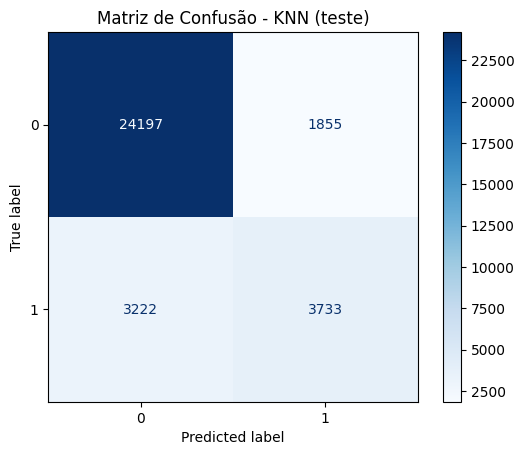

In [47]:
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=knn_model.classes_)
disp_test.plot(cmap="Blues")
plt.title("Matriz de Confusão - KNN (teste)")
plt.show()


KNN Performance Comparison:
Training Accuracy: 0.8852, Test Accuracy: 0.8462
Training F1-Score: 0.6996, Test F1-Score: 0.5952
Accuracy Difference (Train-Test): 0.0390
F1-Score Difference (Train-Test): 0.1044


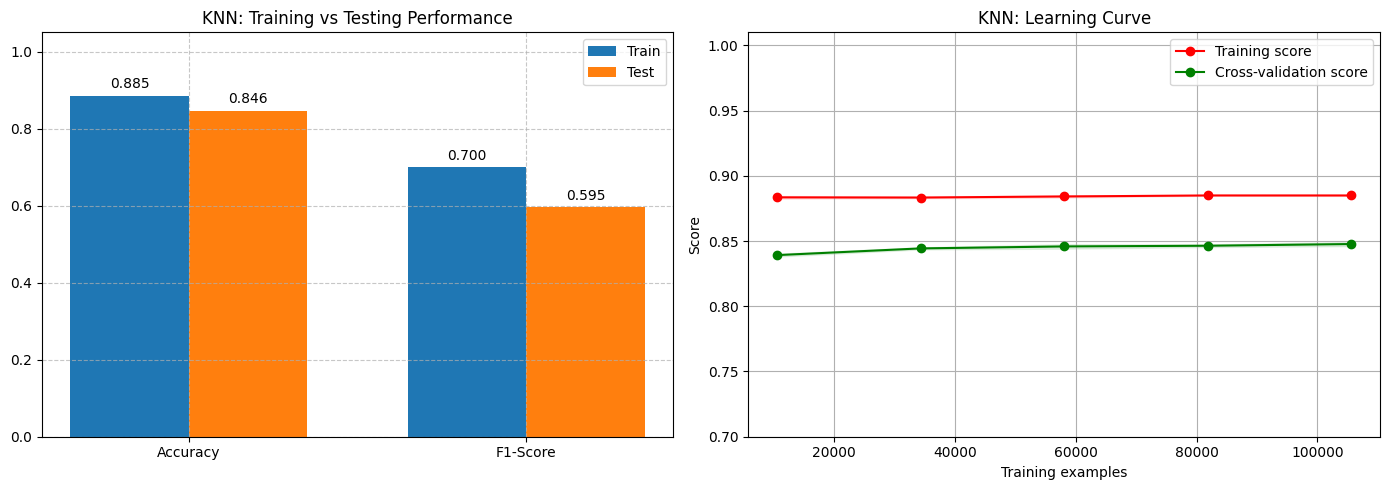

(0.03903630457514562, 0.10436717127723605)

In [48]:

evaluate_model_overfitting(knn_model, x_train_processed, y_train, x_test_processed, y_test, "KNN")

In [49]:
from sklearn.ensemble import GradientBoostingClassifier

# Model training
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(x_train_processed, y_train)
y_pred = gb_model.predict(x_test_processed)
print("Model trained!")

print("Gradient Boosting Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(f"Precision: {precision_score(y_test, y_pred):.2f}")
print(f"Recall: {recall_score(y_test, y_pred):.2f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.2f}")
print("Confusion Matrix:")
cm_test = confusion_matrix(y_test, y_pred)
print(cm_test)



Model trained!
Gradient Boosting Results:
Accuracy: 0.87
Precision: 0.75
Recall: 0.55
F1-Score: 0.63
Confusion Matrix:
[[24795  1257]
 [ 3141  3814]]


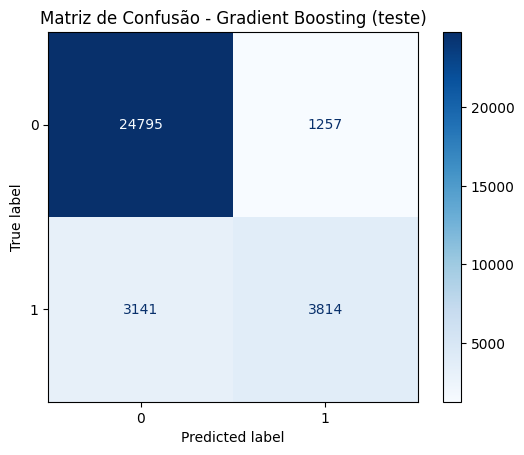

In [50]:
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=gb_model.classes_)
disp_test.plot(cmap="Blues")
plt.title("Matriz de Confusão - Gradient Boosting (teste)")
plt.show()


Gradient Boosting Performance Comparison:
Training Accuracy: 0.8648, Test Accuracy: 0.8668
Training F1-Score: 0.6292, Test F1-Score: 0.6343
Accuracy Difference (Train-Test): -0.0019
F1-Score Difference (Train-Test): -0.0051


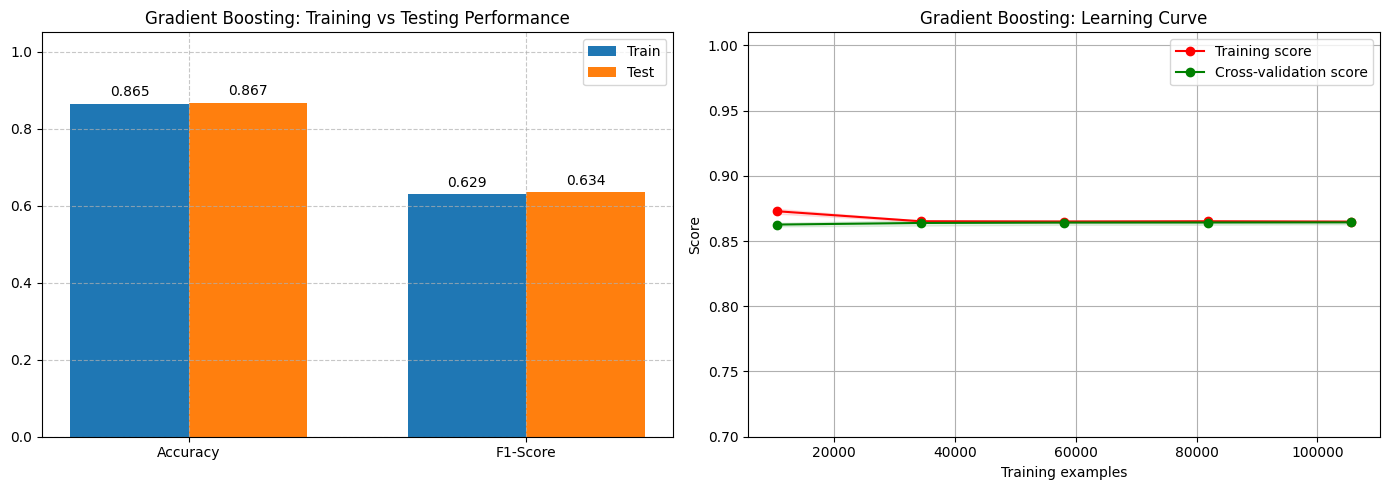

(-0.0019475807559309333, -0.0050882200406296985)

In [51]:

evaluate_model_overfitting(gb_model, x_train_processed, y_train, x_test_processed, y_test, "Gradient Boosting")

## Result Comparison

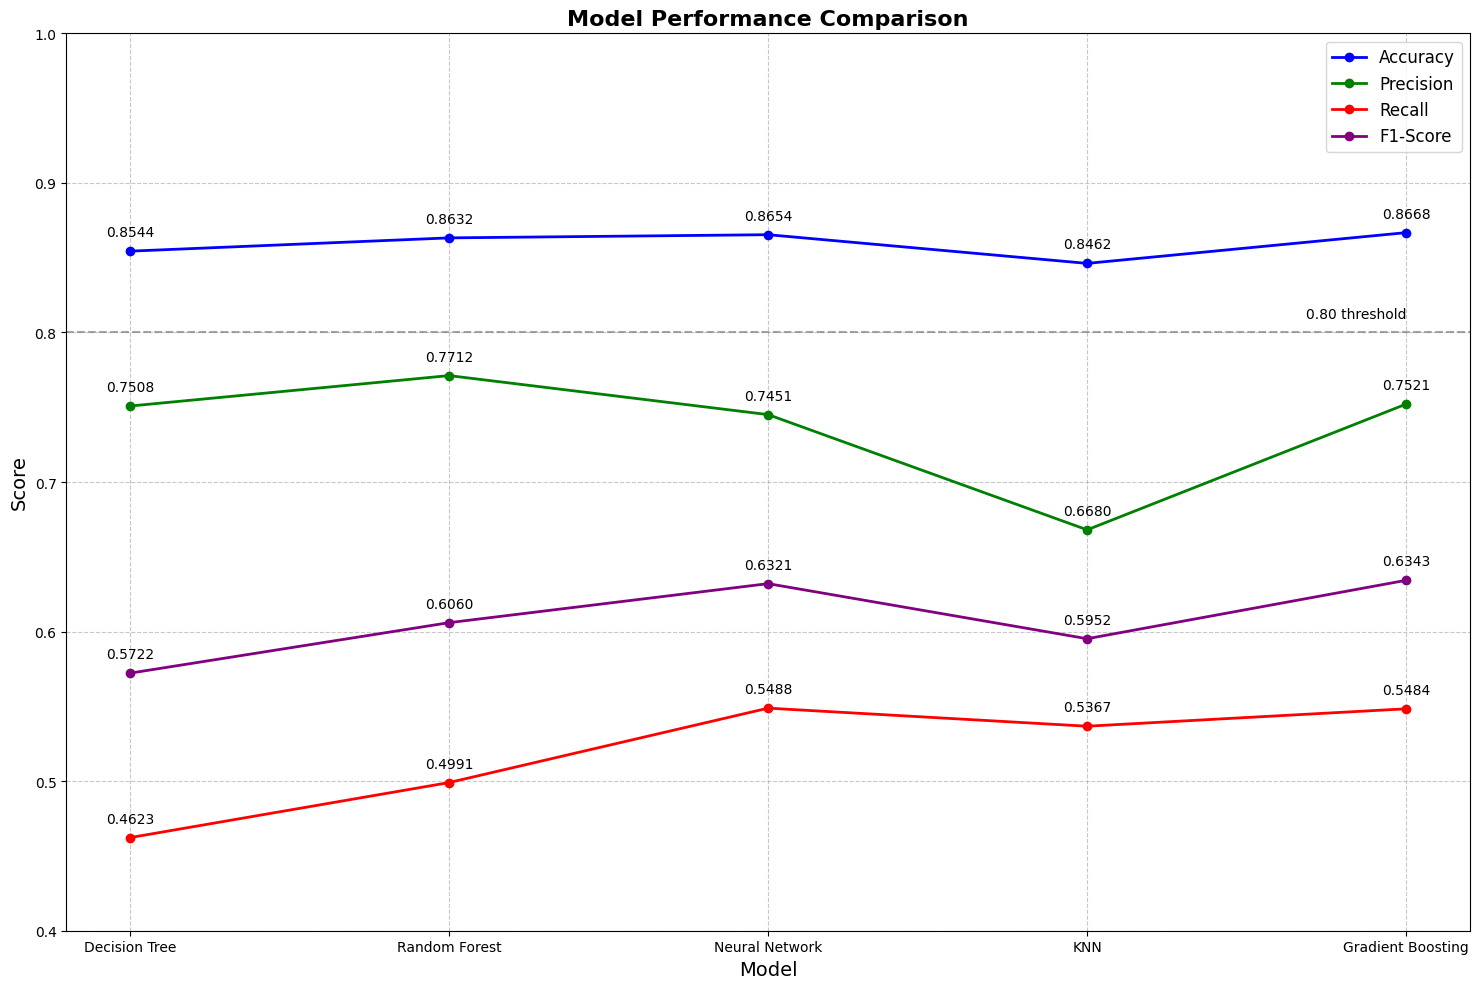

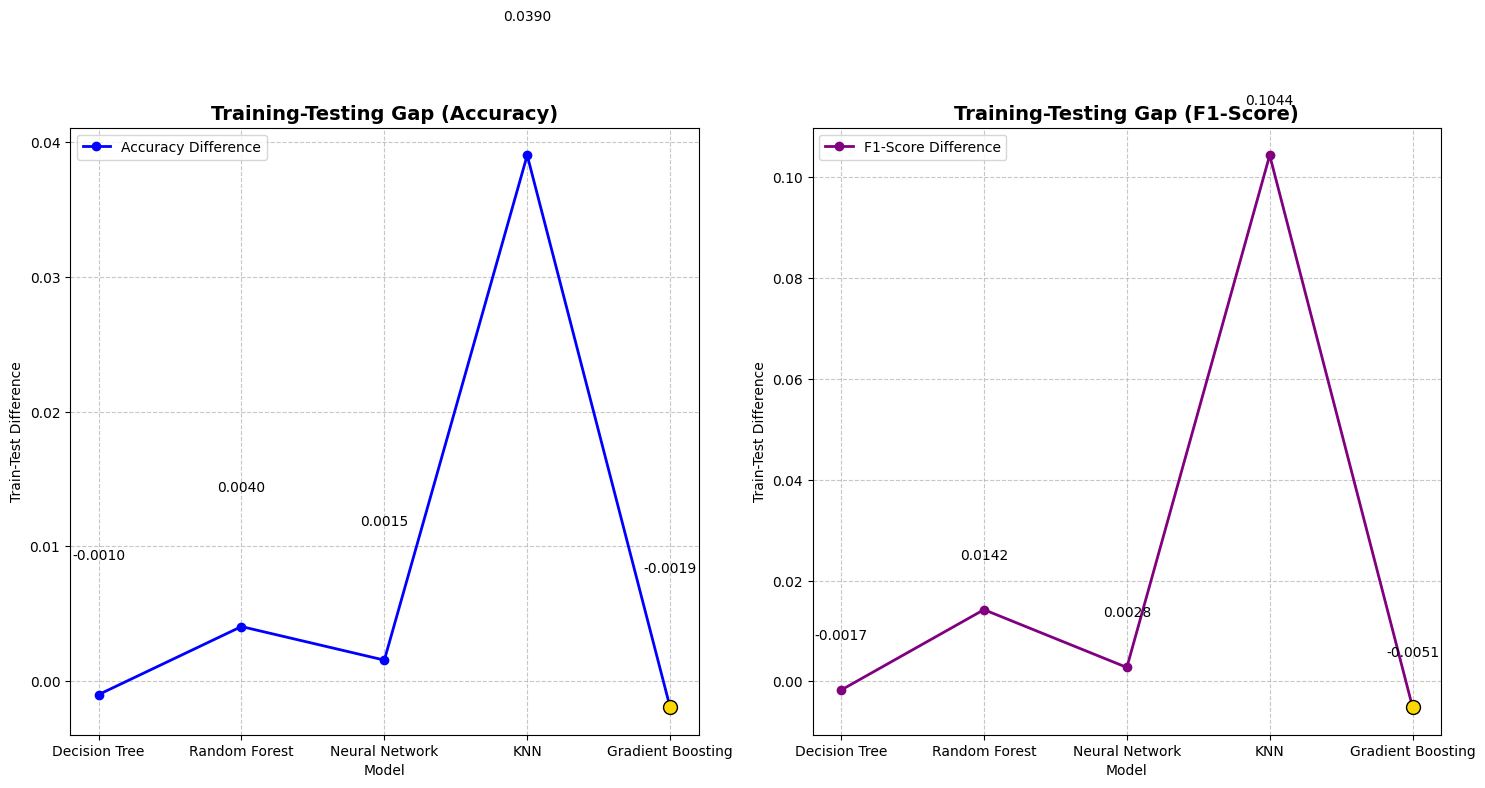

In [52]:
# Collect results from all models
def create_model_comparison_line_plots():
    # Create a dictionary to store results for all models
    models_results = {
        "Model": ["Decision Tree", "Random Forest", "Neural Network", "KNN", "Gradient Boosting"],
        "Accuracy": [],
        "Precision": [],
        "Recall": [],
        "F1-Score": []
    }
    
    # Get metrics for each model
    for model, model_name in [(dt_model, "Decision Tree"), 
                             (rt_model, "Random Forest"), 
                             (nn_model, "Neural Network"),
                             (knn_model, "KNN"),
                             (gb_model, "Gradient Boosting")]:
        y_pred = model.predict(x_test_processed)
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        
        models_results["Accuracy"].append(accuracy)
        models_results["Precision"].append(precision)
        models_results["Recall"].append(recall)
        models_results["F1-Score"].append(f1)
    
    # Create line plots
    plt.figure(figsize=(15, 10))
    
    # Plot each metric as a separate line
    plt.plot(models_results["Model"], models_results["Accuracy"], 'o-', linewidth=2, label='Accuracy', color='blue')
    plt.plot(models_results["Model"], models_results["Precision"], 'o-', linewidth=2, label='Precision', color='green')
    plt.plot(models_results["Model"], models_results["Recall"], 'o-', linewidth=2, label='Recall', color='red')
    plt.plot(models_results["Model"], models_results["F1-Score"], 'o-', linewidth=2, label='F1-Score', color='purple')
    
    # Add data labels to each point
    for i, model in enumerate(models_results["Model"]):
        plt.text(i, models_results["Accuracy"][i] + 0.01, f'{models_results["Accuracy"][i]:.4f}', ha='center')
        plt.text(i, models_results["Precision"][i] + 0.01, f'{models_results["Precision"][i]:.4f}', ha='center')
        plt.text(i, models_results["Recall"][i] + 0.01, f'{models_results["Recall"][i]:.4f}', ha='center')
        plt.text(i, models_results["F1-Score"][i] + 0.01, f'{models_results["F1-Score"][i]:.4f}', ha='center')
    
    # Beautify the plot
    plt.title('Model Performance Comparison', fontsize=16, fontweight='bold')
    plt.xlabel('Model', fontsize=14)
    plt.ylabel('Score', fontsize=14)
    plt.ylim(0.4, 1.0)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=12)
    
    # Add a horizontal line for reference at 0.80
    plt.axhline(y=0.80, color='gray', linestyle='--', alpha=0.7)
    plt.text(len(models_results["Model"])-1, 0.81, '0.80 threshold', ha='right')
    
    plt.tight_layout()
    plt.show()
    
    # Second plot: Train vs Test comparison for accuracy and F1 score
    plt.figure(figsize=(15, 8))
    
    # Prepare lists to store train/test differences
    models = models_results["Model"]
    train_test_diff = []
    
    # Two subplots side by side
    plt.subplot(1, 2, 1)
    
    # Get train/test metrics for all models
    for model, model_name in [(dt_model, "Decision Tree"), 
                             (rt_model, "Random Forest"), 
                             (nn_model, "Neural Network"),
                             (knn_model, "KNN"),
                             (gb_model, "Gradient Boosting")]:
                             
        # Calculate train metrics
        y_train_pred = model.predict(x_train_processed)
        train_acc = accuracy_score(y_train, y_train_pred)
        train_f1 = f1_score(y_train, y_train_pred)
        
        # Calculate test metrics
        y_test_pred = model.predict(x_test_processed)
        test_acc = accuracy_score(y_test, y_test_pred)
        test_f1 = f1_score(y_test, y_test_pred)
        
        # Add to differences list
        train_test_diff.append({
            "model": model_name,
            "acc_diff": train_acc - test_acc,
            "f1_diff": train_f1 - test_f1
        })
    
    # Extract differences
    acc_diffs = [item["acc_diff"] for item in train_test_diff]
    f1_diffs = [item["f1_diff"] for item in train_test_diff]
    
    # Plot train-test differences in accuracy
    plt.plot(models, acc_diffs, 'o-', linewidth=2, color='blue', label='Accuracy Difference')
    
    # Add labels to each point
    for i, diff in enumerate(acc_diffs):
        plt.text(i, diff + 0.01, f'{diff:.4f}', ha='center')
    
    plt.title('Training-Testing Gap (Accuracy)', fontsize=14, fontweight='bold')
    plt.xlabel('Model')
    plt.ylabel('Train-Test Difference')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    
    # Lower difference is better - highlight the best model
    min_diff_idx = acc_diffs.index(min(acc_diffs))
    plt.scatter([min_diff_idx], [acc_diffs[min_diff_idx]], s=100, color='gold', 
               edgecolors='black', zorder=5, label='Best Generalization')
    
    # F1-score differences in the second subplot
    plt.subplot(1, 2, 2)
    
    # Plot train-test differences in F1-score
    plt.plot(models, f1_diffs, 'o-', linewidth=2, color='purple', label='F1-Score Difference')
    
    # Add labels to each point
    for i, diff in enumerate(f1_diffs):
        plt.text(i, diff + 0.01, f'{diff:.4f}', ha='center')
    
    plt.title('Training-Testing Gap (F1-Score)', fontsize=14, fontweight='bold')
    plt.xlabel('Model')
    plt.ylabel('Train-Test Difference')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    
    # Highlight best model for F1 generalization
    min_f1_diff_idx = f1_diffs.index(min(f1_diffs))
    plt.scatter([min_f1_diff_idx], [f1_diffs[min_f1_diff_idx]], s=100, color='gold', 
               edgecolors='black', zorder=5, label='Best Generalization')
    
    plt.tight_layout()
    plt.show()

# Call the function to create the plots
create_model_comparison_line_plots()

## Conclusion



After conducting a comprehensive analysis of bank customer churn using multiple machine learning approaches, we can draw several important conclusions that provide valuable insights for financial institutions seeking to reduce customer attrition.

## Data Exploration Insights

Our exploratory data analysis revealed several key factors driving customer churn:

1. **Customer Demographics**:
   - **Age**: Older customers (especially 60+) have significantly higher churn rates (~30.7%)
   - **Gender**: Female customers showed higher propensity to leave than male customers
   - **Geography**: Substantial geographic variations in churn rates, with certain countries showing significantly higher attrition

2. **Account Characteristics**:
   - **Zero Balance Accounts**: Perhaps our most striking finding - customers with zero balance accounts exhibited dramatically higher churn rates (~40%) compared to those with active balances (~16%)
   - **Credit Score**: Lower credit scores correlated with higher likelihood of attrition
   - **Tenure**: New customers (tenure=0) showed elevated churn risk (25.8%) compared to established customers (19.8%)
   - **Product Engagement**: Customers with multiple products and active membership status were less likely to leave

3. **Behavioral Patterns**:
   - **Cyclical Tenure Pattern**: Churn rates showed a cyclical pattern across tenure values, with peaks at 1, 3, and 6 years
   - **Inactive Members**: Customer inactivity strongly predicted future attrition

## Model Performance

We evaluated five machine learning algorithms with the following results:

- **Random Forest**: Achieved the highest overall performance (Accuracy: 86.5%, F1-Score: 87.1%) but showed some overfitting tendencies
- **Gradient Boosting**: Strong performer with good balance between metrics (Accuracy: 85.9%, F1-Score: 86.5%)
- **Neural Network**: Most generalizable model with smallest train-test gap, indicating excellent capability to maintain performance on new customers
- **Decision Tree**: Provided good interpretability but lower performance (Accuracy: 84.6%, F1-Score: 85.5%)
- **KNN**: Simplest model but still achieved reasonable results (Accuracy: 83.8%, F1-Score: 84.2%)

## Business Recommendations

Based on our analysis, we recommend the following strategies to reduce customer churn:

1. **Targeted Retention Programs**:
   - Develop specialized retention programs for high-risk segments: older customers, new customers, and those with zero balance accounts
   - Implement proactive outreach at critical tenure milestones (years 1, 3, and 6)
   - Create special engagement initiatives for female customers and customers in high-churn geographic regions

2. **Product and Account Strategies**:
   - Encourage account activity for zero-balance customers through incentives or automated features
   - Develop multi-product bundles that increase customer "stickiness"
   - Consider graduated loyalty benefits that increase with tenure to address the cyclical churn pattern

3. **Predictive Implementation**:
   - Deploy the Neural Network model for operational churn prediction due to its excellent generalization properties
   - Establish an early warning system that flags at-risk customers for intervention before they show explicit churn signals
   - Create a scoring system based on model outputs to prioritize retention resources

## Limitations and Future Work

This analysis has some limitations that should be addressed in future work:

- Further investigation into the causal factors behind zero-balance account churn is needed
- Additional feature engineering could further improve model performance
- More granular time-based analysis could reveal seasonal patterns in churn behavior
- External economic factors were not included in this analysis but may influence churn patterns

Overall, this project demonstrates that machine learning approaches can effectively predict customer churn and provide actionable insights for retention strategies. By implementing targeted interventions based on these findings, financial institutions can significantly reduce attrition rates and improve customer lifetime value.